# Machine Learning project autumn 2024

Authors: Dimitar Kochev, Mihael Stoyanov <br>

Reqired imports:



In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from functools import partial
import tensorflow as tf
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Conv2D, MaxPooling2D, Dropout, BatchNormalization 
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from collections import Counter


# Exploratory data analysis

### Load data:

In [36]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [37]:
# Devide features and labels
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]
test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]

## Visualisations
### Distribution of classes in train set

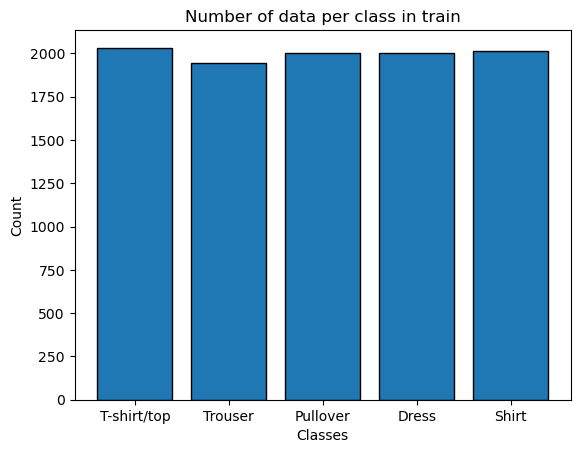

In [38]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

### Dimensionality reduction with PCA

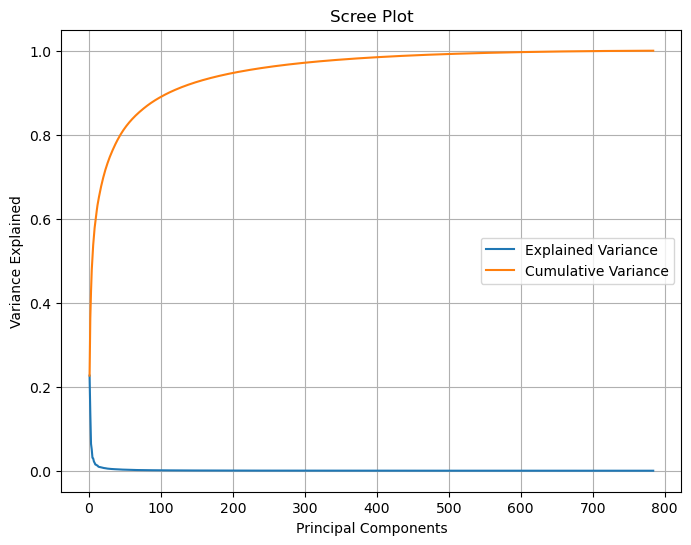

In [39]:
#PCA on whole data
scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Class distribution in 2 components space

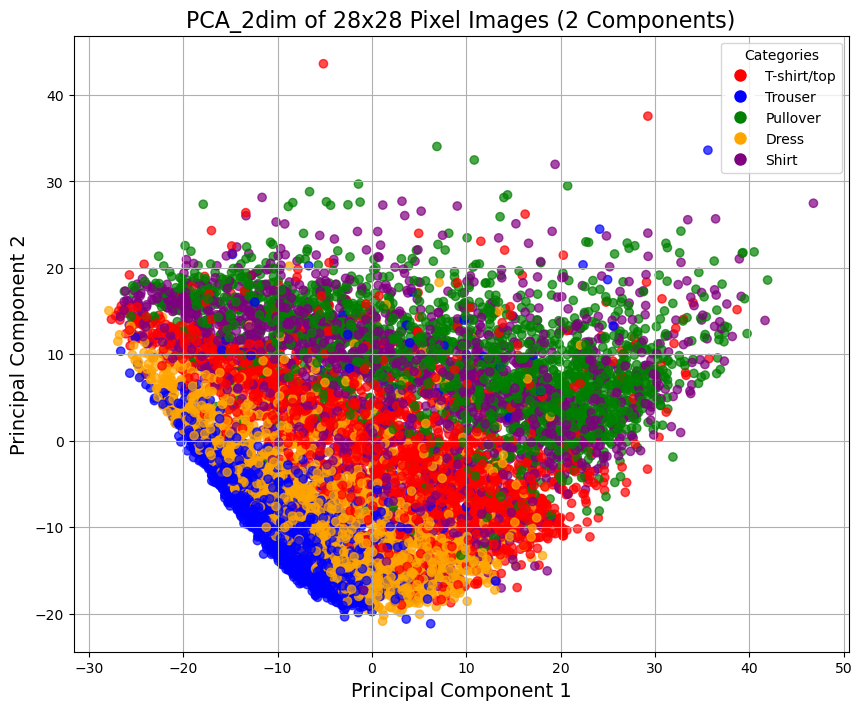

In [ ]:
X_scaled = scaler.fit_transform(train_data_X)
pca_2dim = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca_2dim.fit_transform(X_scaled)

# Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in train_data_y]  # Assign colors based on the labels

# Visualize the PCA_2dim results in 2D
plt.figure(figsize=(10, 8))
plt.scatter(principal_df['PC1'], principal_df['PC2'], 
            alpha=0.7, c=point_colors)

# Labels and title
plt.title('PCA_2dim of 28x28 Pixel Images (2 Components)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
plt.legend(handles=legend_handles, title='Categories')

plt.grid()
plt.show()


Example for an image with different components

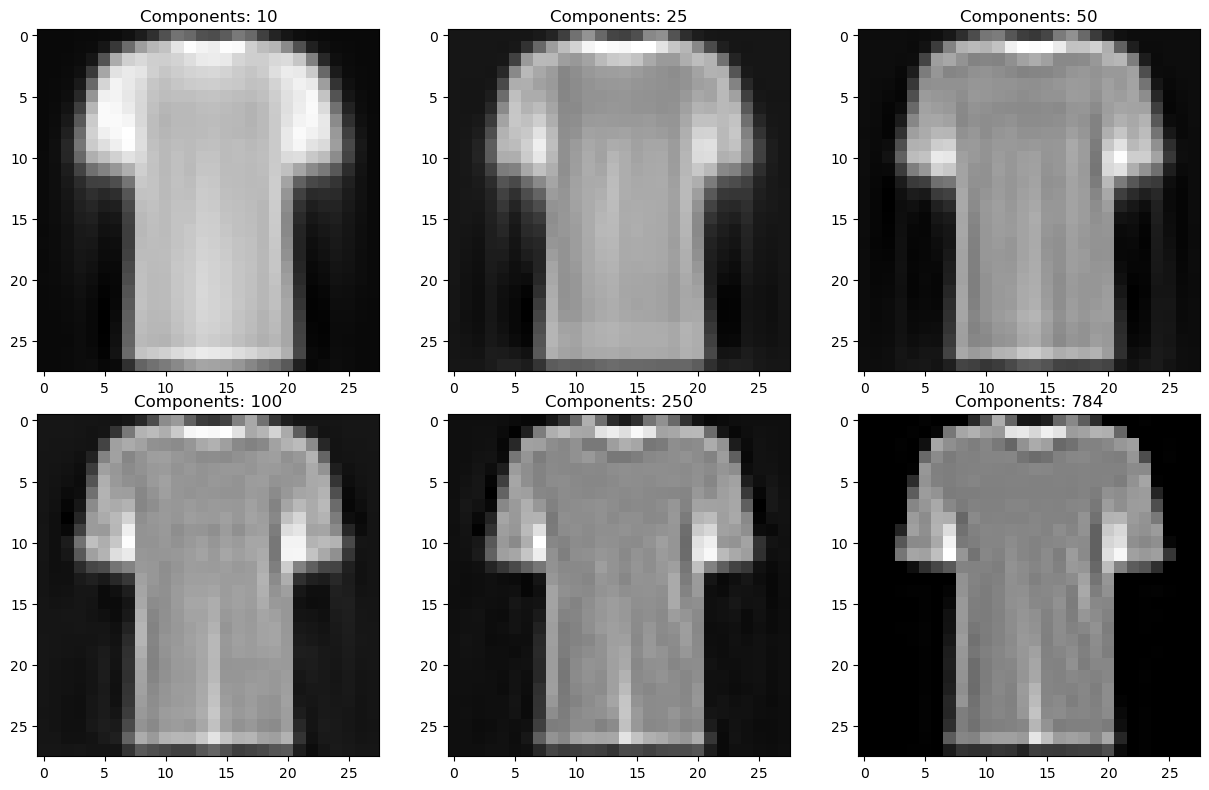

In [ ]:
def plot_at_k(k):
    # Perform Incremental PCA with k components
    ipca = IncrementalPCA(n_components=k)
    # Reconstruct the first image from the transformed data
    image_recon = ipca.inverse_transform(ipca.fit_transform(train_data_X))[0].reshape(28, 28)
    # Plot the reconstructed image
    plt.imshow(image_recon, cmap=plt.cm.gray)

# List of components to use for PCA
ks = [10, 25, 50, 100, 250, 784]
plt.figure(figsize=[15, 10])

# Plot the reconstructed images for each k
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plot_at_k(ks[i])
    plt.title("Components: " + str(ks[i]))

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.2, hspace=0.0)
plt.show()

We chose to use 100 components. The reason behind this is that we want to have a relativly low number of features but also to retain high variance. In 100 components we retain 89.01% of the original information. So we concider this as a good combination.

In [42]:
#We save our PCA for external analysis and 
# Transforms data to 100 components
X_scaled_train = scaler.fit_transform(train_data_X)
pca_100dim = PCA(n_components=100)
X_reduced_100=pca_100dim.fit_transform(X_scaled_train)

X_scaled_test = scaler.fit_transform(test_data_X)
test_X_reduced_100=pca_100dim.transform(X_scaled_test)

# Classification models

## 1.Manual implementations
### 1.1 Decicion tree

Our implementation:

In [43]:

class TreeNode:
    def __init__(self, data, feature_idx, feature_val, prediction_probs):
        self.data = data
        self.feature_idx = feature_idx
        self.feature_val = feature_val
        self.prediction_probs = prediction_probs
        self.left = None
        self.right = None

    def node_def(self):
        unique_values, value_counts = np.unique(self.data[:, -1], return_counts=True)
        output = ", ".join([f"{value}->{count}" for value, count in zip(unique_values, value_counts)])
        return f"LEAF | Label Counts = {output} | Pred Probs = {self.prediction_probs}"

class DecisionTreeFromScratch:
    def __init__(self, max_depth, min_leaf):
        self.max_depth = max_depth
        self.min_leaf = min_leaf
        self.tree = None

    def _entropy(self, class_probabilities):
        return sum([-p * np.log2(p) for p in class_probabilities if p > 0])

    def _class_probabilities(self, labels):
        total_count = len(labels)
        return [count / total_count for count in Counter(labels).values()]

    def _data_entropy(self, labels):
        return self._entropy(self._class_probabilities(labels))

    def _partition_entropy(self, subsets):
        total_count = sum(len(subset) for subset in subsets)
        return sum(self._data_entropy(subset) * (len(subset) / total_count) for subset in subsets)

    def _split_indices(self, data, feature_index, feature_val):
        mask = data[:, feature_index] < feature_val
        return np.where(mask)[0], np.where(~mask)[0]

    def _find_best_split(self, data):
        min_part_entropy = float('inf')
        best_split = None
        n_features = data.shape[1] - 1  # Exclude label column

        for idx in range(n_features):
            feature_vals = np.percentile(data[:, idx], q=np.linspace(0, 100, num=20))  # Optimize thresholds
            for feature_val in feature_vals:
                left_idx, right_idx = self._split_indices(data, idx, feature_val)
                if len(left_idx) == 0 or len(right_idx) == 0:  # Skip invalid splits
                    continue
                part_entropy = self._partition_entropy([data[left_idx, -1], data[right_idx, -1]])
                if part_entropy < min_part_entropy:
                    min_part_entropy = part_entropy
                    best_split = (left_idx, right_idx, idx, feature_val, min_part_entropy)

        return best_split if best_split else (None, None, None, None, None)

    def _find_label_probs(self, labels):
        total_labels = len(labels)
        label_probabilities = np.zeros(len(self.labels_in_train), dtype=float)
        for i, label in enumerate(self.labels_in_train):
            count = np.sum(labels == label)
            label_probabilities[i] = count / total_labels
        return label_probabilities

    def _create_tree(self, data, indices, current_depth):
        if current_depth >= self.max_depth or len(indices) < self.min_leaf:
            return None

        split = self._find_best_split(data[indices])
        if not split:
            return None

        left_idx, right_idx, split_feature_idx, split_feature_val, _ = split
        left_data_indices = indices[left_idx]
        right_data_indices = indices[right_idx]
        label_probabilities = self._find_label_probs(data[indices, -1])

        node = TreeNode(data[indices], split_feature_idx, split_feature_val, label_probabilities)
        if len(left_data_indices) < self.min_leaf or len(right_data_indices) < self.min_leaf:
            return node

        current_depth += 1
        node.left = self._create_tree(data, left_data_indices, current_depth)
        node.right = self._create_tree(data, right_data_indices, current_depth)
        return node

    def _predict_one_sample(self, X):
        node = self.tree
        while node.left or node.right:
            if X[node.feature_idx] < node.feature_val:
                node = node.left
            else:
                node = node.right
        return node.prediction_probs

    def fit(self, X_train, Y_train):
        self.labels_in_train = np.unique(Y_train)
        train_data = np.concatenate((X_train, np.reshape(Y_train, (-1, 1))), axis=1)
        indices = np.arange(len(train_data))
        self.tree = self._create_tree(data=train_data, indices=indices, current_depth=0)

    def predict_proba(self, X_set):
        return np.apply_along_axis(self._predict_one_sample, 1, X_set)

    def predict(self, X_set):
        pred_probs = self.predict_proba(X_set)
        return np.argmax(pred_probs, axis=1)

    def evaluate_model(self, X_val, y_val, labels):
        predictions = self.predict(X_val)
        accuracy = accuracy_score(y_val, predictions)
        recall_per_class = recall_score(y_val, predictions, average=None, labels=labels)
        conf_matrix = confusion_matrix(y_val, predictions, labels=labels)

        print("Overall Accuracy:", accuracy)
        print("Recall per Class:")
        for label, recall in zip(labels, recall_per_class):
            print(f"Class {label}: {recall:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)

        return accuracy, recall_per_class, conf_matrix

# Main Code: Data Loading and Cross-Validation


In [44]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_recalls = []
fold_conf_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"\nTraining Fold {fold + 1}")

    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]

    house_plant = DecisionTreeFromScratch(max_depth=10, min_leaf=10)
    house_plant.fit(X_train, y_train)
    labels = np.unique(y_train)

    accuracy, recall_per_class, conf_matrix = house_plant.evaluate_model(X_val, y_val, labels)
    fold_accuracies.append(accuracy)
    fold_recalls.append(recall_per_class)
    fold_conf_matrices.append(conf_matrix)
    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))

# Print Final Results
print("\nFinal Cross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.2f}")
print("Mean Recall per Class:", np.mean(fold_recalls, axis=0))


Training Fold 1
Overall Accuracy: 0.781
Recall per Class:
Class 0: 0.8241
Class 1: 0.9472
Class 2: 0.7912
Class 3: 0.8494
Class 4: 0.5085

Confusion Matrix:
 [[342  10  14  19  30]
 [  4 359   1  13   2]
 [ 11   9 307   7  54]
 [ 30  10  11 344  10]
 [ 93   8  73  29 210]]
Fold 1 Accuracy: 0.7810

Training Fold 2
Overall Accuracy: 0.7535
Recall per Class:
Class 0: 0.7236
Class 1: 0.9262
Class 2: 0.7812
Class 3: 0.8333
Class 4: 0.4974

Confusion Matrix:
 [[288   5   9  33  63]
 [  4 364   5  15   5]
 [ 16   2 332  16  59]
 [ 19  17   7 330  23]
 [ 82  10  79  24 193]]
Fold 2 Accuracy: 0.7535

Training Fold 3
Overall Accuracy: 0.7715
Recall per Class:
Class 0: 0.7519
Class 1: 0.9271
Class 2: 0.7978
Class 3: 0.8693
Class 4: 0.5376

Confusion Matrix:
 [[300   4   6  26  63]
 [  3 369   1  14  11]
 [  2   4 292  10  58]
 [ 22  10   6 346  14]
 [ 78   8  84  33 236]]
Fold 3 Accuracy: 0.7715

Training Fold 4
Overall Accuracy: 0.7815
Recall per Class:
Class 0: 0.7251
Class 1: 0.8816
Class 2: 

### 1.2 Feed-forward neural network

Our implementation:

In [93]:

def one_hot_encode(Y, num_classes):
    return np.eye(num_classes)[Y]

#define neural network layer
class Layer():
    def __init__(self, n_num, input_dim):
        self.weights = self.initialize_parameters(n_num, input_dim)
        self.gamma = np.ones((n_num, 1))  # Scaling factor
        self.beta = np.zeros((n_num, 1)) 

    def initialize_parameters(self, n_num, input_dim):
        """Initialize parameters with He initialization method"""
        
        parameters = {}
        parameters["W"] = np.random.randn(n_num, input_dim) * np.sqrt(2/input_dim)
        parameters["b"] = np.zeros((n_num, 1))

        return parameters
#define optimizer   
class Adam_optimizer():
    def __init__(self, learning_rate, beta1, beta2, epsilon):
        self.momentum_w = {}
        self.momentum_b = {}
        self.rms_w = {}
        self.rms_b = {}
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.learning_rate = learning_rate
        self.t = 0  # Time step for bias correction

    def update_parameters(self, parameters, gradients):
        self.t += 1  # Increment time step
        
        # Update parameters for each layer
        for l_num, l in enumerate(parameters, start=1):
            if l_num not in self.momentum_w:
                # Initialize moment and RMSprop caches if not already done
                self.momentum_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.momentum_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
                self.rms_w[l_num] = np.zeros_like(parameters[l_num-1][0].weights['W'])
                self.rms_b[l_num] = np.zeros_like(parameters[l_num-1][0].weights['b'])
            
            # Momentum updates
            self.momentum_w[l_num] = self.beta1 * self.momentum_w[l_num] + (1 - self.beta1) * gradients["dW" + str(l_num)]
            self.momentum_b[l_num] = self.beta1 * self.momentum_b[l_num] + (1 - self.beta1) * gradients["db" + str(l_num)]
            
            # RMS updates
            self.rms_w[l_num] = self.beta2 * self.rms_w[l_num] + (1 - self.beta2) * (gradients["dW" + str(l_num)]**2)
            self.rms_b[l_num] = self.beta2 * self.rms_b[l_num] + (1 - self.beta2) * (gradients["db" + str(l_num)]**2)
            
            # Bias correction
            momentum_w_corr = self.momentum_w[l_num] / (1 - self.beta1**self.t)
            momentum_b_corr = self.momentum_b[l_num] / (1 - self.beta1**self.t)
            rms_w_corr = self.rms_w[l_num] / (1 - self.beta2**self.t)
            rms_b_corr = self.rms_b[l_num] / (1 - self.beta2**self.t)

            # Update weights and biases
            l[0].weights['W'] -= self.learning_rate * (momentum_w_corr / (np.sqrt(rms_w_corr) + self.epsilon))
            l[0].weights['b'] -= self.learning_rate * (momentum_b_corr / (np.sqrt(rms_b_corr) + self.epsilon))
            
        return parameters

class Mini_Batch_GD_optimizer():
    def __init__(self, learning_rate, decay_rate=0.01):
        self.learning_rate = learning_rate
        self.decay_rate = decay_rate
    
    def update_parameters(self, parameters, gradients, epoch):
        # Apply learning rate decay
        decayed_learning_rate = self.learning_rate * np.exp(-self.decay_rate * epoch)
        l_num = 0
        for l in parameters:
            # Update weights and biases
            l[0].weights['W'] -= decayed_learning_rate * gradients["dW" + str(l_num)]
            l[0].weights['b'] -= decayed_learning_rate * gradients["db" + str(l_num)]
            l_num += 1
        return parameters
    
#define fnn    
class FFNN():
    """
    A class used to represent a Feed-Forward Neural Network (FFNN).
    Attributes
    ----------
    layers : list
        A list to store the layers of the neural network.
    optimizer : object
        The optimizer used for training the neural network.
    metrics : dict
        A dictionary to store the metrics for evaluation.
    early_stopping : dict or None
        A dictionary to store early stopping parameters or None if not used.
    Methods
    -------
    add_layer(n_num, input_dim=None, activation="relu"):
        Adds a layer to the neural network.
    compile(optimizer='adam', learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, metrics=['accuracy'], early_stopping=None):
        Configures the neural network for training.
    fit(X_train, Y_train, X_val=None, Y_val=None, batch_size=32, epochs=0):
        Trains the neural network on the training data.
    feed_forward(temp_weights, I):
        Performs the forward pass through the network.
    backward_prop(parameters, forward_vars, Y):
        Performs the backward pass and computes gradients.
    predict(X):
        Predicts the output for the given input data.
    _activate(I, activation):
        Applies the specified activation function.
    get_stats(Y_hat, Y):
        Computes and stores evaluation metrics.
    """
    def __init__(self):
        self.layers=[]
        self.optimizer=None
        self.metrics={}
        self.early_stopping = None
    
    def add_layer(self, n_num, input_dim=None, activation="relu"):
        """
        Adds a layer to the neural network.
        Parameters
        ----------
        n_num : int
            Number of neurons in the layer.
        input_dim : int, optional
            Dimension of the input to the layer. Must be provided for the first layer.
        activation : str, optional
            Activation function to use in the layer. Default is "relu".
        """
        if input_dim is None:
            if len(self.layers) == 0:
                raise ValueError("Input dimension must be provided for the first layer.")
            input_dim = len(self.layers[-1][0].weights['W'])
        new_layer = Layer(n_num, input_dim)
        self.layers.append([new_layer, activation])
    
    def compile(self, optimizer='adam', learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, metrics=['accuracy'], early_stopping=None):
        """
        Configures the neural network for training.
        Parameters
        ----------
        optimizer : str, optional
            Optimizer to use for training. Default is 'adam'.
        learning_rate : float, optional
            Learning rate for the optimizer. Default is 0.001.
        beta1 : float, optional
            Exponential decay rate for the first moment estimates in Adam optimizer. Default is 0.9.
        beta2 : float, optional
            Exponential decay rate for the second moment estimates in Adam optimizer. Default is 0.999.
        epsilon : float, optional
            Small constant for numerical stability in Adam optimizer. Default is 1e-8.
        metrics : list, optional
            List of metrics to evaluate during training. Default is ['accuracy'].
        early_stopping : dict or None, optional
            Dictionary to store early stopping parameters or None if not used. Default is None.
        """
        if optimizer=='adam':
            self.optimizer=Adam_optimizer(learning_rate, beta1, beta2, epsilon )
        elif optimizer=='mini':
            self.optimizer=Mini_Batch_GD_optimizer(learning_rate)
        for m in metrics: self.metrics.update({m : []})
        self.early_stopping = early_stopping
        
    def fit(self, X_train, Y_train, X_val=None, Y_val=None, batch_size=32, epochs=0):
        """
        Trains the neural network on the training data.
        Parameters
        ----------
        X_train : numpy.ndarray
            Training data.
        Y_train : numpy.ndarray
            Training labels.
        X_val : numpy.ndarray, optional
            Validation data. Default is None.
        Y_val : numpy.ndarray, optional
            Validation labels. Default is None.
        batch_size : int, optional
            Size of the mini-batches. Default is 32.
        epochs : int, optional
            Number of epochs to train the model. Default is 0.
        """
        self.minibatch_size = batch_size
        temp_weights=self.layers.copy()
        best_weights = None
        best_epoch = 0
        best_val_loss = float('inf')
        patience_counter = 0

        for i in range(epochs):
            for batch_idx in range(0, int(X_train.shape[0] / batch_size)):
                # Mini Batch Samples
                if batch_idx == int(X_train.shape[1] / batch_size):
                    X = X_train[:, batch_idx*batch_size:]
                    Y = Y_train[:, batch_idx*batch_size:]
                else:
                    X = X_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]
                    Y = Y_train[:, batch_idx*batch_size: (batch_idx+1)*batch_size]

                output_history = self.feed_forward(temp_weights, X)
                gradients = self.backward_prop(temp_weights, output_history, Y)
                temp_weights = self.optimizer.update_parameters(temp_weights, gradients)
            
            history=self.feed_forward(temp_weights, X_train)
            predictions = history["A"+str(len(self.layers))]
            y_pred =np.argmax(predictions, axis=0) 
            if 'loss' in self.metrics.keys():
                self.metrics['loss'].append(-np.sum(Y_train * np.log(np.clip(predictions, 1e-10, 1.0)  + 10**-100))/int(Y_train.shape[1]))
            self.get_stats(y_pred, Y_train.T)
            if X_val is not None or Y_val is not None:
                # Validation loss
                val_history = self.feed_forward(temp_weights, X_val)
                val_predictions = val_history["A"+str(len(self.layers))]
                self.metrics['val_accuracy'].append(accuracy_score(Y_val.T, one_hot_encode(np.argmax(val_predictions, axis=0),5)))
                val_predictions = np.clip(val_predictions, 1e-10, 1.0) 
                val_loss = -np.sum(Y_val * np.log(val_predictions + 10**-100))/int(Y_val.shape[1])
                self.metrics['val_loss'].append(val_loss)
                
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_weights = temp_weights.copy()
                    best_epoch = i
                    patience_counter = 0
                else:
                    patience_counter += 1

                if self.early_stopping and patience_counter >= self.early_stopping['patience']:
                    print(f"Early stopping at epoch {i+1}")
                    break

                self.layers = best_weights
                print(f"Best epoch: {best_epoch+1}, Best validation loss: {best_val_loss}")
            else:
                self.layers = temp_weights.copy()
                
           
    def feed_forward(self, temp_weights, I):
        """
        Performs the forward pass through the network.
        Parameters
        ----------
        temp_weights : list
            List of layers with their weights and activation functions.
        I : numpy.ndarray
            Input data.
        Returns
        -------
        forward_vars : dict
            Dictionary containing the intermediate variables of the forward pass.
        """
        forward_vars = {"A0": I}
        running_mean, running_var = {}, {}
        
        for l_num in range(1, len(temp_weights) + 1):
            layer = temp_weights[l_num - 1]
            forward_vars["Z"+str(l_num)] = np.dot(layer[0].weights['W'], forward_vars["A" + str(l_num - 1)]) + layer[0].weights['b']

            # Batch Normalization
            mean = np.mean(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z"+str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z"+str(l_num)] - mean) / np.sqrt(var + 1e-8)
            Z_bn = layer[0].gamma * Z_norm + layer[0].beta

            # Save running mean and variance for inference
            running_mean[l_num] = mean
            running_var[l_num] = var

            # Activation
            forward_vars["Z" + str(l_num)] = Z_bn
            forward_vars["A" + str(l_num)] = self._activate(Z_bn, layer[1])
        return forward_vars
    
    def backward_prop(self, parameters, forward_vars, Y):
        """
        Performs the backward pass and computes gradients.
        Parameters
        ----------
        parameters : list
            List of layers with their weights and activation functions.
        forward_vars : dict
            Dictionary containing the intermediate variables of the forward pass.
        Y : numpy.ndarray
            True labels.
        Returns
        -------
        gradients : dict
            Dictionary containing the gradients of the weights and biases.
        """
        gradients = {}
        l_num = len(parameters)

        for l_num in range(len(parameters), 0, -1):
            m = forward_vars["A" + str(l_num - 1)].shape[1]
            layer = parameters[l_num - 1]

            if layer[1] == 'sigmoid':
                gradients["dA" + str(l_num)] = -np.divide(Y, forward_vars["A" + str(l_num)]) + np.divide((1 - Y), (1 - forward_vars["A" + str(l_num)]))
                gradients["dZ" + str(l_num)] = gradients["dA" + str(l_num)] * forward_vars["A" + str(l_num)] * (1 - forward_vars["A" + str(l_num)])
            elif layer[1] == 'relu':
                relu_derivative = forward_vars["A"+str(l_num)] > 0
                gradients["dZ"+str(l_num)] = np.multiply(gradients["dA"+str(l_num)], relu_derivative)
            elif layer[1] == "leaky_relu":
                leaky_relu_derivative = np.where(forward_vars["A" + str(l_num)] > 0, 1, 0.01)
                gradients["dZ" + str(l_num)] = np.multiply(gradients["dA" + str(l_num)], leaky_relu_derivative)
            elif layer[1] == 'softmax':
                gradients["dZ"+str(l_num)] = forward_vars["A"+str(l_num)] - Y 
            
            dZ = gradients["dZ" + str(l_num)]
            mean = np.mean(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            var = np.var(forward_vars["Z" + str(l_num)], axis=1, keepdims=True)
            Z_norm = (forward_vars["Z" + str(l_num)] - mean) / np.sqrt(var + 1e-8)

            gradients["dgamma" + str(l_num)] = np.sum(dZ * Z_norm, axis=1, keepdims=True)
            gradients["dbeta" + str(l_num)] = np.sum(dZ, axis=1, keepdims=True)
            dZ_norm = dZ * layer[0].gamma

            dvar = np.sum(dZ_norm * (forward_vars["Z" + str(l_num)] - mean) * -0.5 * (var + 1e-8) ** (-1.5), axis=1, keepdims=True)
            dmean = np.sum(dZ_norm * -1 / np.sqrt(var + 1e-8), axis=1, keepdims=True) + dvar * np.mean(-2 * (forward_vars["Z" + str(l_num)] - mean), axis=1, keepdims=True)
            gradients["dZ" + str(l_num)] = dZ_norm / np.sqrt(var + 1e-8) + dvar * 2 * (forward_vars["Z" + str(l_num)] - mean) / m + dmean / m

            gradients["dW" + str(l_num)] = (1 / m) * np.dot(gradients["dZ" + str(l_num)], forward_vars["A" + str(l_num - 1)].T)
            gradients["db" + str(l_num)] = (1 / m) * np.sum(gradients["dZ" + str(l_num)], axis=1, keepdims=True)
            gradients["dA" + str(l_num - 1)] = np.dot(layer[0].weights['W'].T, gradients["dZ" + str(l_num)])
        return gradients
    
    def predict(self, X):
        """
        Predicts the output for the given input data.
        Parameters
        ----------
        X : numpy.ndarray
            Input data.
        Returns
        -------
        numpy.ndarray
            Predicted output.
        """
        forward_vars = self.feed_forward(self.layers, X)
        L = len(self.layers)
        return forward_vars["A"+str(L)]
    
    def _activate(self, I, activation):
        """
        Applies the specified activation function.
        Parameters
        ----------
        I : numpy.ndarray
            Input data.
        activation : str
            Activation function to apply.
        Returns
        -------
        numpy.ndarray
            Activated output.
        """
        if activation=='relu':
            result=np.maximum(0, I)
        elif activation == 'leaky_relu':
            result = np.where(I > 0, I, 0* I) 
        elif activation=='softmax':
            T = np.exp(I - np.max(I, axis=0, keepdims=True))
            T_sum = np.sum(T, axis=0, keepdims=True)
            result = np.divide(T, T_sum)
        elif activation=='sigmoid':
            result = 1 / (1 + np.exp(-I))
        else:
            print("Error")
        return result
    
    def get_stats(self, Y_hat, Y):
        """
        Computes and stores evaluation metrics.
        Parameters
        ----------
        Y_hat : numpy.ndarray
            Predicted labels.
        Y : numpy.ndarray
            True labels.
        """
        y_pred=one_hot_encode(Y_hat, 5)
        if 'accuracy' in self.metrics.keys():
            accuracy = accuracy_score(Y, y_pred)
            self.metrics['accuracy'].append(accuracy)
        if 'micro_recall' in self.metrics.keys():
            micro_recall = recall_score(Y, y_pred, average='micro')
            self.metrics['micro_recall'].append(micro_recall)
        if 'macro_recall' in self.metrics.keys():
            macro_recall = recall_score(Y, y_pred, average='macro')
            self.metrics['macro_recall'].append(macro_recall)
        if 'weighted_recall' in self.metrics.keys():
            weighted_recall = recall_score(Y, y_pred, average='weighted')
            self.metrics['weighted_recall'].append(weighted_recall)
        return


In [100]:
def create_multiclass_model_from_scratch_raw(input_dim, num_classes):
    model_fnn_s = FFNN()
    model_fnn_s.add_layer(256, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model_fnn_s.add_layer(128, activation='leaky_relu') # First hidden layer
    model_fnn_s.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model_fnn_s.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model_fnn_s.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model_fnn_s.compile(optimizer='adam',learning_rate=0.001,

                 metrics=['accuracy', 'loss','val_accuracy', 'val_loss'], 
                 early_stopping={'patience': 10}
                 )
    return model_fnn_s

def create_multiclass_model_from_scratch_pca(input_dim, num_classes):
    model_fnn_s_100 = FFNN()
    model_fnn_s_100.add_layer(128, input_dim=input_dim, activation='leaky_relu') # First hidden layer
    model_fnn_s_100.add_layer(64, activation='leaky_relu')  # Second hidden layer
    model_fnn_s_100.add_layer(32, activation='leaky_relu')  # Third hidden layer
    model_fnn_s_100.add_layer(num_classes, activation='softmax')  # Output layer for multi-class classification
  
    # Compile the model
    model_fnn_s_100.compile(optimizer='adam',learning_rate=0.001,
                 metrics=['accuracy', 'loss','val_accuracy', 'val_loss'],
                 early_stopping={'patience': 10}
    )
   
    return model_fnn_s_100

In [75]:
def plot_metrics(metrics):
    epochs = range(1, len(metrics['loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['loss'], 'b-', label='Loss')
    if 'val_loss' in metrics and len(metrics['val_loss']) > 0:
        plt.plot(epochs, metrics['val_loss'], 'r--', label='Val Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['accuracy'], 'b-', label='Accuracy')
    if 'val_accuracy' in metrics and len(metrics['val_loss']) > 0:
        plt.plot(epochs, metrics['val_accuracy'], 'r--', label='Val Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

5-fold cross-validation with raw data

Training fold 1
Early stopping at epoch 13
Best epoch: 3, Best validation loss: 0.6827833058437494
Fold 1 Accuracy: 0.8025
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.80      0.74      0.77       415
           1       0.99      0.95      0.97       379
           2       0.74      0.83      0.78       388
           3       0.89      0.85      0.87       405
           4       0.64      0.66      0.65       413

    accuracy                           0.80      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.80      0.80      2000

Confusion Matrix for Fold 1:
 [[309   0  25  16  65]
 [  2 360   6   9   2]
 [  1   0 321   7  59]
 [ 20   2  13 343  27]
 [ 56   3  70  12 272]]


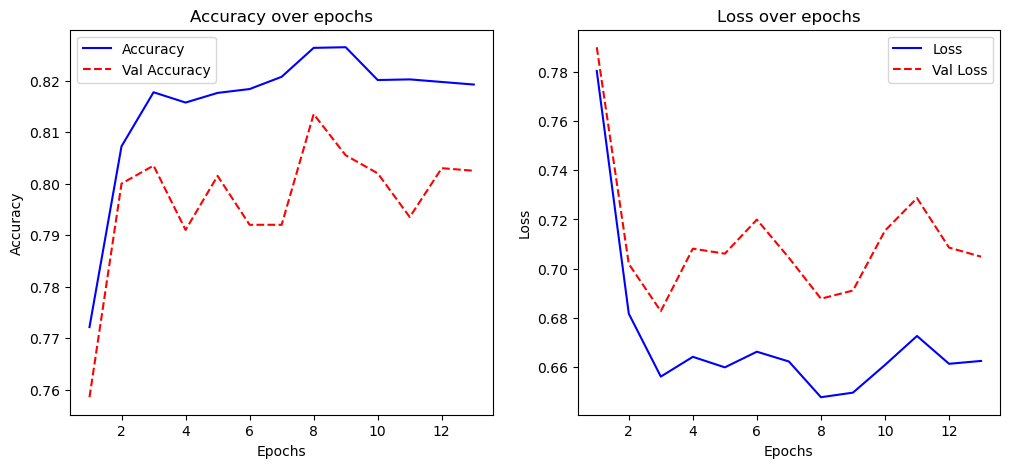

Training fold 2
Early stopping at epoch 67
Best epoch: 57, Best validation loss: 0.6589518431923868
Fold 2 Accuracy: 0.8155
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76       398
           1       0.97      0.97      0.97       393
           2       0.84      0.85      0.84       425
           3       0.88      0.84      0.86       396
           4       0.63      0.65      0.64       388

    accuracy                           0.82      2000
   macro avg       0.82      0.81      0.82      2000
weighted avg       0.82      0.82      0.82      2000

Confusion Matrix for Fold 2:
 [[304   2  10  20  62]
 [  1 380   3   8   1]
 [  4   0 361   5  55]
 [ 23   6   3 334  30]
 [ 67   3  54  12 252]]


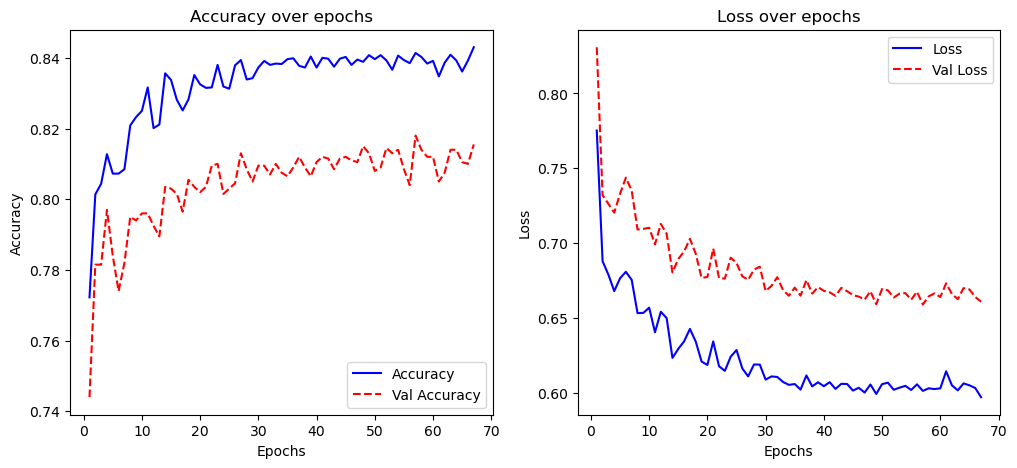

Training fold 3
Early stopping at epoch 30
Best epoch: 20, Best validation loss: 0.663896980724529
Fold 3 Accuracy: 0.8125
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76       399
           1       0.99      0.94      0.96       398
           2       0.77      0.87      0.81       366
           3       0.86      0.88      0.87       398
           4       0.70      0.64      0.67       439

    accuracy                           0.81      2000
   macro avg       0.81      0.82      0.81      2000
weighted avg       0.81      0.81      0.81      2000

Confusion Matrix for Fold 3:
 [[303   0  12  23  61]
 [  0 375   7  13   3]
 [  0   0 317   5  44]
 [ 19   4  11 351  13]
 [ 75   1  67  17 279]]


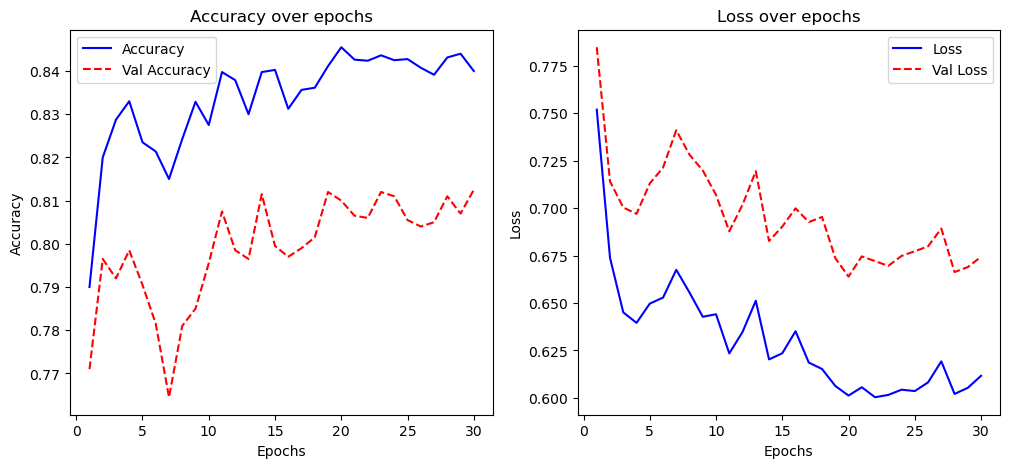

Training fold 4
Early stopping at epoch 50
Best epoch: 40, Best validation loss: 0.6150323973848327
Fold 4 Accuracy: 0.8275
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81       411
           1       0.99      0.92      0.95       414
           2       0.80      0.84      0.82       406
           3       0.89      0.88      0.88       396
           4       0.64      0.70      0.67       373

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000

Confusion Matrix for Fold 4:
 [[322   0   9  20  60]
 [  0 382  11  12   9]
 [  5   0 343   5  53]
 [ 16   4   6 347  23]
 [ 42   1  61   8 261]]


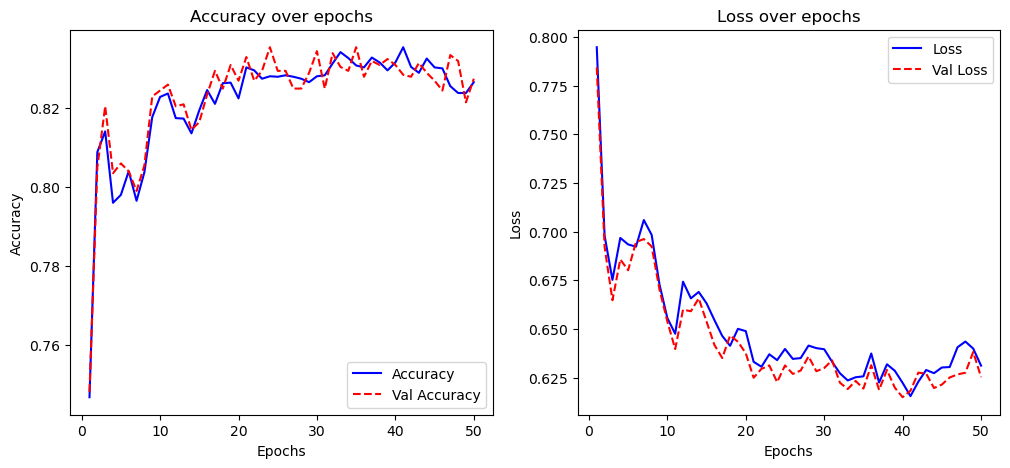

Training fold 5
Early stopping at epoch 82
Best epoch: 72, Best validation loss: 0.6043365305493001
Fold 5 Accuracy: 0.8285
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81       410
           1       0.98      0.93      0.95       363
           2       0.78      0.87      0.82       416
           3       0.88      0.89      0.88       410
           4       0.70      0.67      0.68       401

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000

Confusion Matrix for Fold 5:
 [[326   1  10  15  58]
 [  1 337   8  14   3]
 [  9   1 360   5  41]
 [ 15   3  12 364  16]
 [ 42   2  69  18 270]]


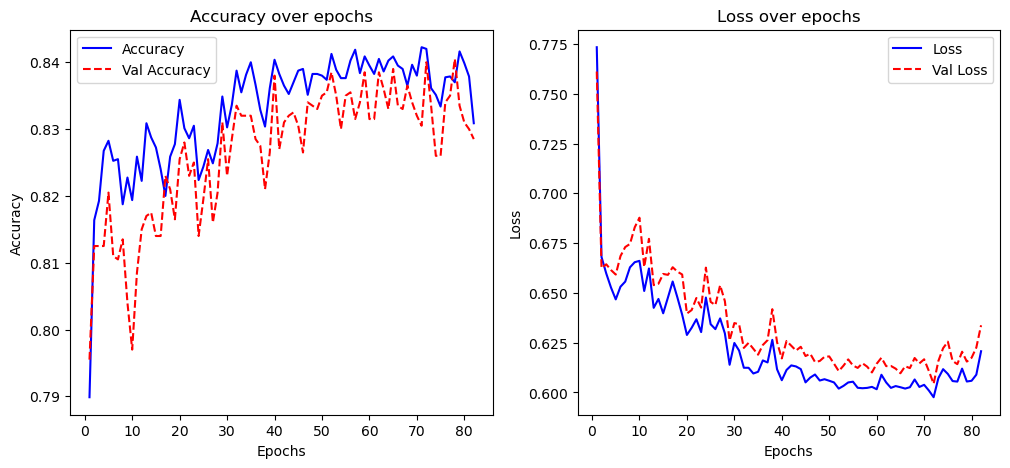


Average Accuracy across 5 folds: 0.8173


In [85]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].T, train_data_X[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    
    # Create a new instance of the model
    model_fnn_s = create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Train the model
    model_fnn_s.fit(X_train, y_train, X_val, Y_val=one_hot_encode(y_val, 5).T , epochs=100, batch_size=32)
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model_fnn_s.predict(X_val), axis=0)  # Get the predicted class for each sample
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_metrics(model_fnn_s.metrics)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")

5-fold cross-validation with 100 components

Training fold 1
Early stopping at epoch 21
Best epoch: 11, Best validation loss: 1.1089773936351262
Fold 1 Accuracy: 0.6250
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.63      0.60      0.61       410
           1       0.87      0.79      0.83       372
           2       0.58      0.61      0.59       408
           3       0.62      0.76      0.68       393
           4       0.45      0.40      0.42       417

    accuracy                           0.62      2000
   macro avg       0.63      0.63      0.63      2000
weighted avg       0.63      0.62      0.62      2000

Confusion Matrix for Fold 1:
 [[245  11  18  66  70]
 [  9 293   9  52   9]
 [ 38   8 248  24  90]
 [ 24  16  23 298  32]
 [ 71   8 133  39 166]]


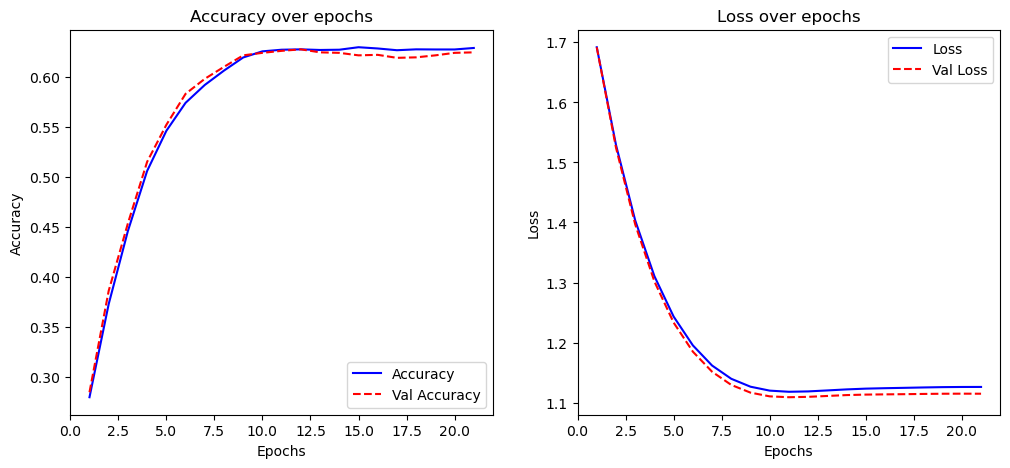

Training fold 2
Early stopping at epoch 45
Best epoch: 35, Best validation loss: 1.1274819087713317
Fold 2 Accuracy: 0.6175
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.65      0.61      0.63       412
           1       0.78      0.79      0.79       402
           2       0.53      0.53      0.53       383
           3       0.65      0.76      0.70       385
           4       0.45      0.40      0.43       418

    accuracy                           0.62      2000
   macro avg       0.61      0.62      0.62      2000
weighted avg       0.61      0.62      0.61      2000

Confusion Matrix for Fold 2:
 [[253  24  35  47  53]
 [ 22 319  13  40   8]
 [ 15  22 202  25 119]
 [ 20  21  25 292  27]
 [ 79  22 105  43 169]]


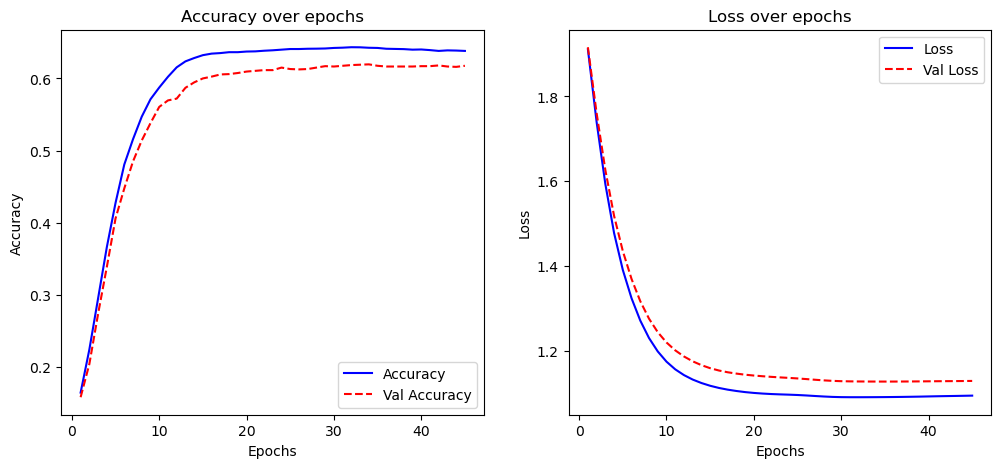

Training fold 3
Early stopping at epoch 28
Best epoch: 18, Best validation loss: 1.1157163473771008
Fold 3 Accuracy: 0.6255
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.62      0.62      0.62       419
           1       0.86      0.85      0.86       364
           2       0.63      0.50      0.56       383
           3       0.70      0.70      0.70       429
           4       0.39      0.47      0.42       405

    accuracy                           0.63      2000
   macro avg       0.64      0.63      0.63      2000
weighted avg       0.64      0.63      0.63      2000

Confusion Matrix for Fold 3:
 [[258  10  24  55  72]
 [ 14 310   2  22  16]
 [ 28   6 192   9 148]
 [ 30  23  12 302  62]
 [ 88  10  74  44 189]]


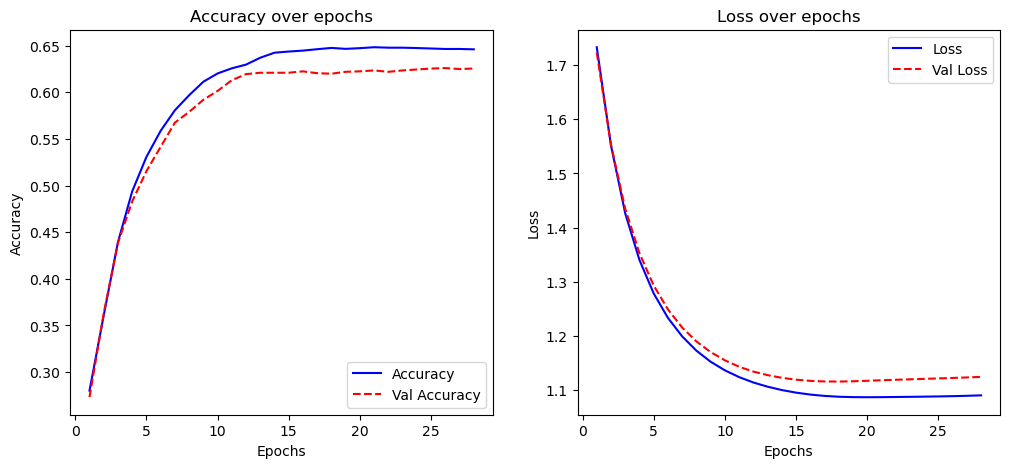

Training fold 4
Early stopping at epoch 28
Best epoch: 18, Best validation loss: 1.0046835829880052
Fold 4 Accuracy: 0.6755
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.61      0.64      0.63       393
           1       0.84      0.91      0.87       417
           2       0.70      0.63      0.66       415
           3       0.75      0.73      0.74       393
           4       0.45      0.45      0.45       382

    accuracy                           0.68      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.68      0.67      2000

Confusion Matrix for Fold 4:
 [[251  14  20  41  67]
 [  2 379   4  18  14]
 [ 29  21 262  15  88]
 [ 34  21   8 288  42]
 [ 93  16  80  22 171]]


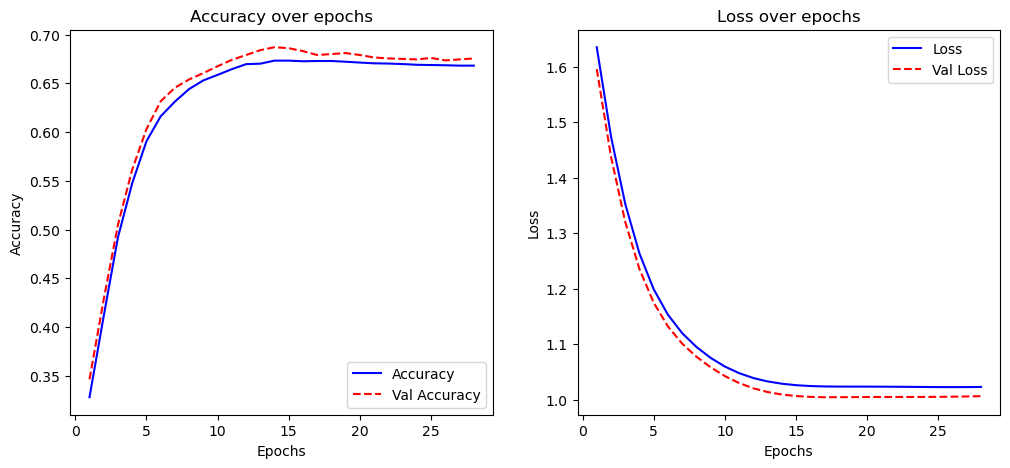

Training fold 5
Early stopping at epoch 31
Best epoch: 21, Best validation loss: 1.0737779537391465
Fold 5 Accuracy: 0.6445
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.57      0.57      0.57       399
           1       0.82      0.89      0.85       392
           2       0.64      0.52      0.57       412
           3       0.72      0.77      0.74       405
           4       0.46      0.49      0.48       392

    accuracy                           0.64      2000
   macro avg       0.64      0.65      0.64      2000
weighted avg       0.64      0.64      0.64      2000

Confusion Matrix for Fold 5:
 [[227  12  33  52  75]
 [  8 347   6  23   8]
 [ 45  16 213  23 115]
 [ 32  27  12 310  24]
 [ 88  21  67  24 192]]


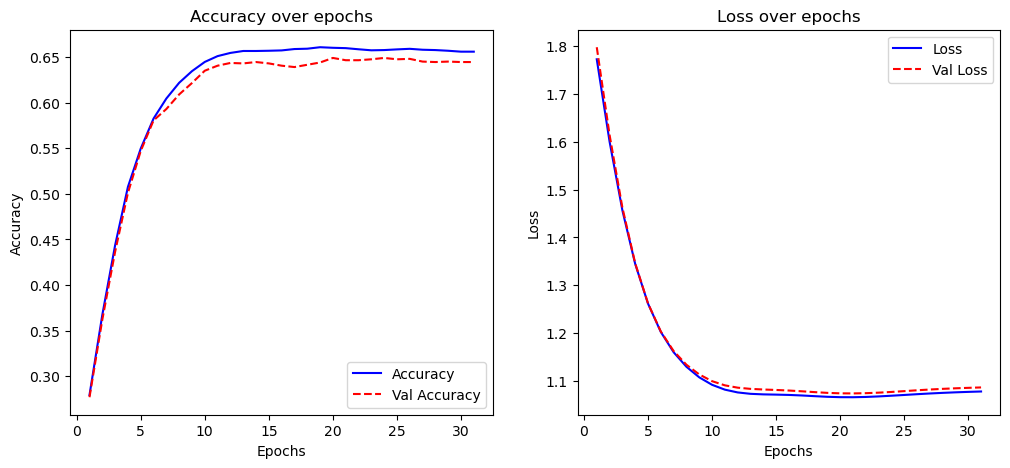


Average Accuracy across 5 folds: 0.6376


In [49]:
kf = KFold(n_splits=5, shuffle=True)
fold_accuracies_pca = []
all_classification_reports_pca = []
all_confusion_matrices_pca = []

# Split the data into training and validation sets for the current fold   
for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index].T, X_reduced_100[val_index].T
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    y_train = one_hot_encode(y_train, 5).T
    # Create a new instance of the model
    model_fnn_s_100 = create_multiclass_model_from_scratch_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    
    
    # Train the model
    model_fnn_s_100.fit(X_train, y_train, X_val, one_hot_encode(y_val, 5).T, epochs=100, batch_size=32)

    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model_fnn_s_100.predict(X_val), axis=0)  # Get the predicted class for each sample
    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies_pca.append(accuracy_pca)
    
    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports_pca.append(class_report)
    all_confusion_matrices_pca.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_metrics(model_fnn_s_100.metrics)

# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies_pca)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

## 2. Reference  implementations
### 2.1 Decicion tree

Grid search with raw data

In [52]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [ 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['log2', None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(train_data_X, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validated accuracy score: 0.8028000000000001


Grid search with 100 components data

In [53]:
#Grid search for best parameters
param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': [None]
}

# Initialize the Decision Tree model
dt = tree.DecisionTreeClassifier()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_reduced_100, train_data_y)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy score:", grid_search.best_score_)

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validated accuracy score: 0.7668999999999999


## 2.2 Feed-forward neural network

Model building

In [54]:
def create_multiclass_model_raw(input_dim, num_classes):
    model_fnn_tf = Sequential()
    model_fnn_tf.add(Dense(256, input_dim=input_dim, activation='leaky_relu'))
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(128, activation='leaky_relu'))  # First hidden layer
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_fnn_tf.add(BatchNormalization())
    model_fnn_tf.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model_fnn_tf.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model_fnn_tf.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model_fnn_tf

def create_multiclass_model_pca(input_dim, num_classes):
    model_fnn_tf_100 = Sequential()
    model_fnn_tf_100.add(Dense(128, input_dim=input_dim, activation='leaky_relu'))  # First hidden layer
    model_fnn_tf_100.add(BatchNormalization())
    model_fnn_tf_100.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_fnn_tf_100.add(BatchNormalization())
    model_fnn_tf_100.add(Dense(32, activation='leaky_relu'))  # Third hidden layer
    model_fnn_tf_100.add(Dense(num_classes, activation='softmax'))  # Output layer for multi-class classification
    
    # Compile the model
    model_fnn_tf_100.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if using one-hot encoding
                  metrics=['accuracy'])
    return model_fnn_tf_100

In [56]:
def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
    else:
        plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
        plt.title('Training and Validation Loss')
    else:
        plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()

5-fold cross-validation with raw data

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 1 Accuracy: 0.8560
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83       415
           1       0.99      0.96      0.97       379
           2       0.87      0.87      0.87       388
           3       0.88      0.90      0.89       405
           4       0.77      0.67      0.72       413

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.85      2000

Confusion Matrix for Fold 1:
 [[367   0   6  13  29]
 [  5 363   2   5   4]
 [  3   0 339  10  36]
 [ 21   3   1 366  14]
 [ 72   0  41  23 277]]


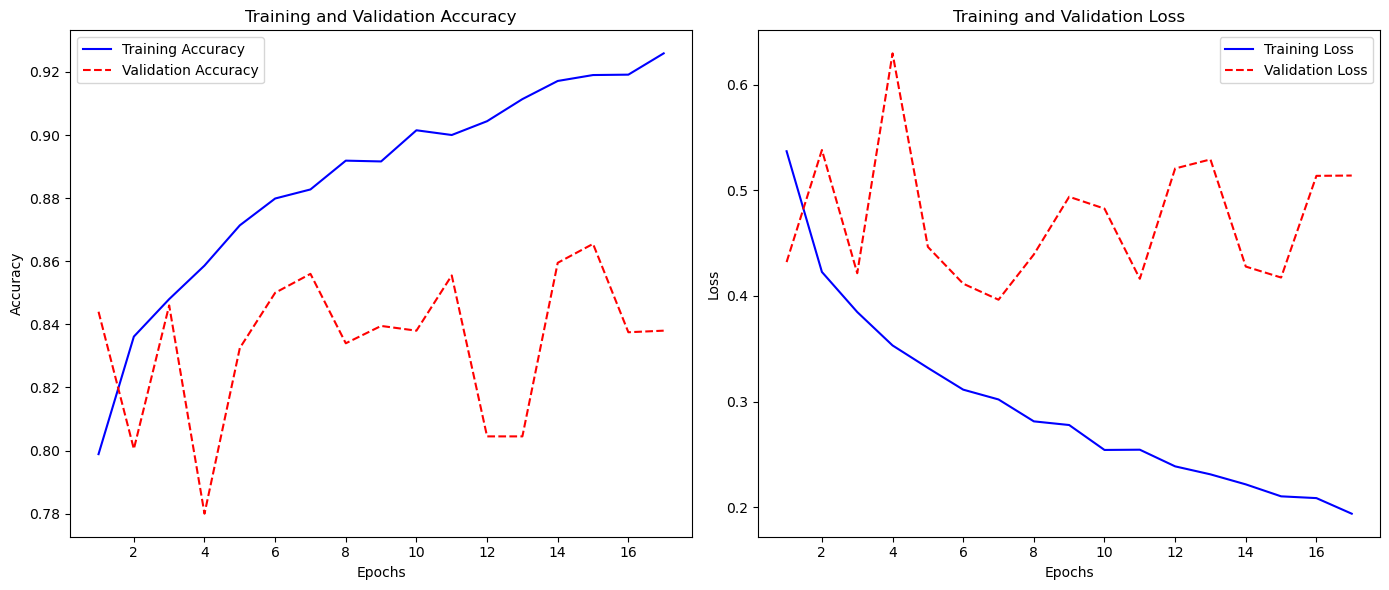

Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 2 Accuracy: 0.8465
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.79      0.80      0.79       398
           1       0.99      0.97      0.98       393
           2       0.82      0.92      0.87       425
           3       0.88      0.93      0.90       396
           4       0.74      0.61      0.67       388

    accuracy                           0.85      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.85      0.84      2000

Confusion Matrix for Fold 2:
 [[318   0   7  23  50]
 [  2 381   1   8   1]
 [ 10   0 389   7  19]
 [ 10   2   3 369  12]
 [ 64   1  74  13 236]]


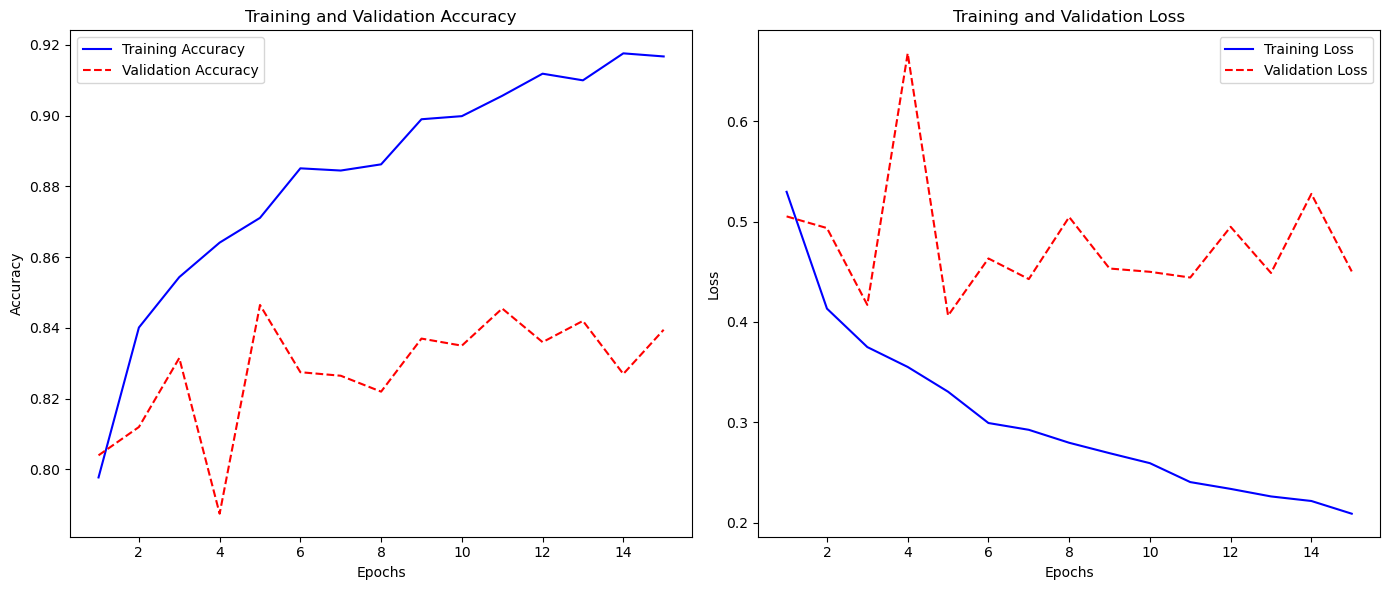

Training fold 3


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 3 Accuracy: 0.8520
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       399
           1       0.99      0.96      0.98       398
           2       0.85      0.87      0.86       366
           3       0.87      0.92      0.89       398
           4       0.79      0.68      0.73       439

    accuracy                           0.85      2000
   macro avg       0.85      0.86      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 3:
 [[339   1   4  13  42]
 [  2 383   0  12   1]
 [  6   1 320   7  32]
 [ 22   0   6 365   5]
 [ 71   1  46  24 297]]


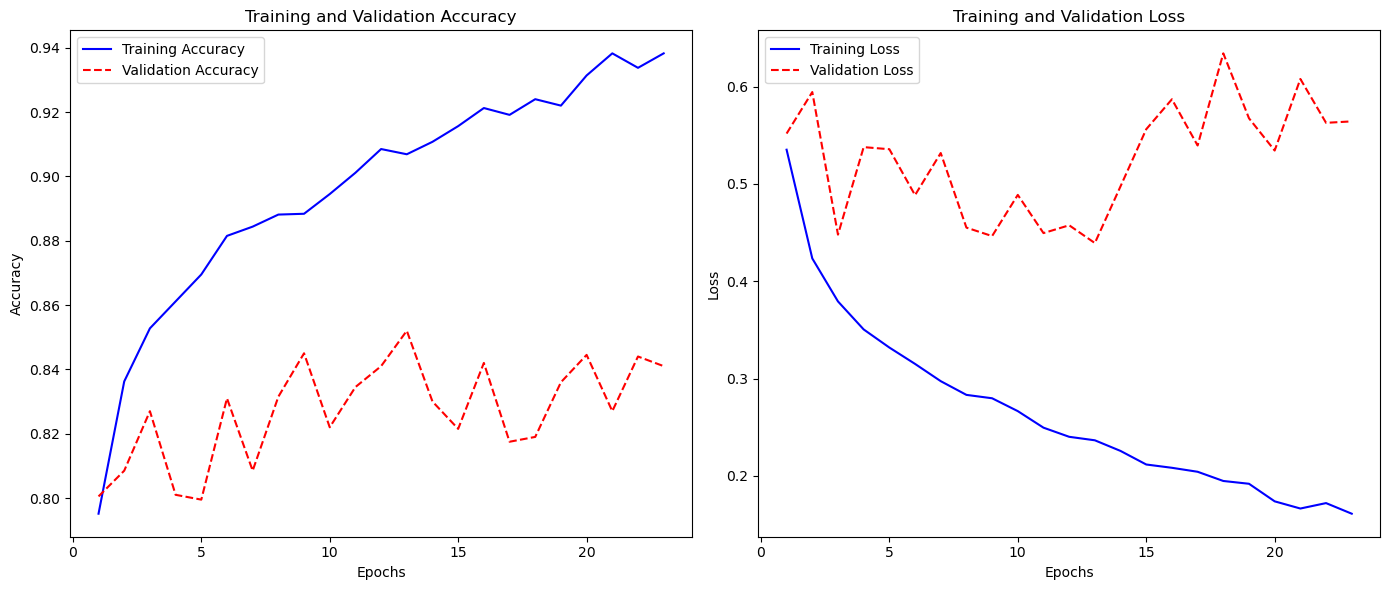

Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 Accuracy: 0.8615
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       411
           1       1.00      0.96      0.98       414
           2       0.84      0.92      0.88       406
           3       0.89      0.91      0.90       396
           4       0.78      0.61      0.68       373

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 4:
 [[367   0   7  12  25]
 [  1 397   1  13   2]
 [  8   0 372   8  18]
 [ 14   1   2 360  19]
 [ 74   0  59  13 227]]


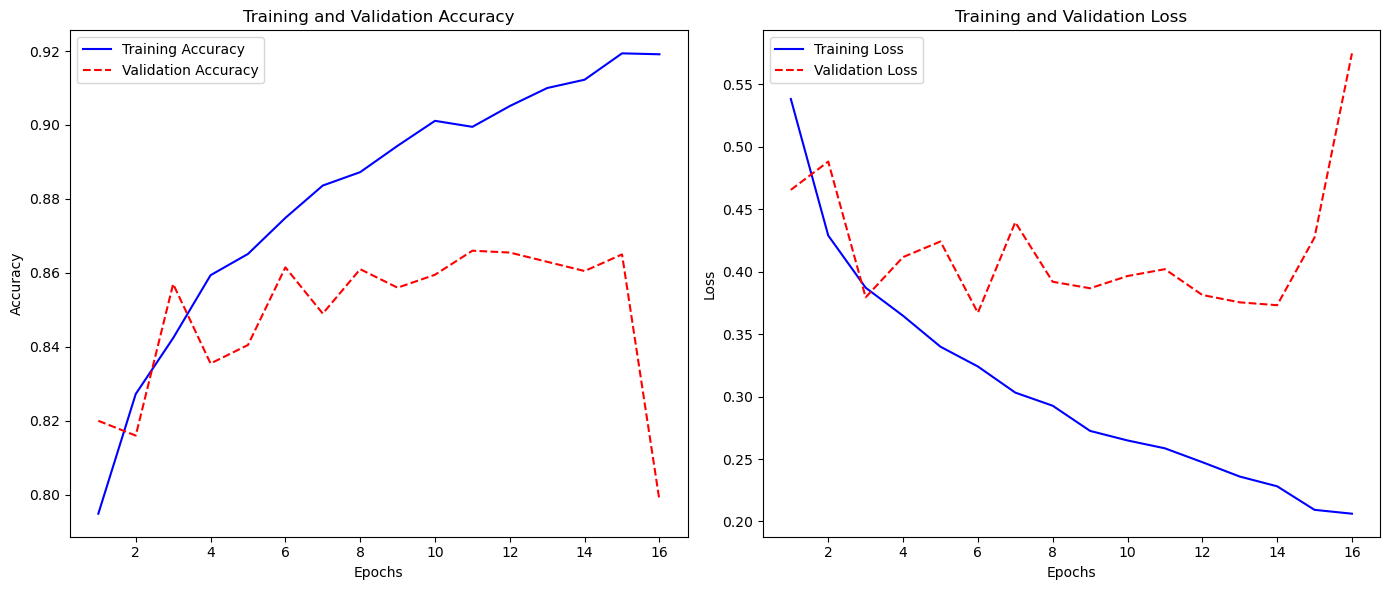

Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 5 Accuracy: 0.8465
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       410
           1       0.97      0.95      0.96       363
           2       0.88      0.81      0.84       416
           3       0.91      0.88      0.90       410
           4       0.70      0.73      0.71       401

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Confusion Matrix for Fold 5:
 [[359   1   3   6  41]
 [  3 345   0  14   1]
 [  8   5 335   4  64]
 [ 16   3   8 361  22]
 [ 61   0  36  11 293]]


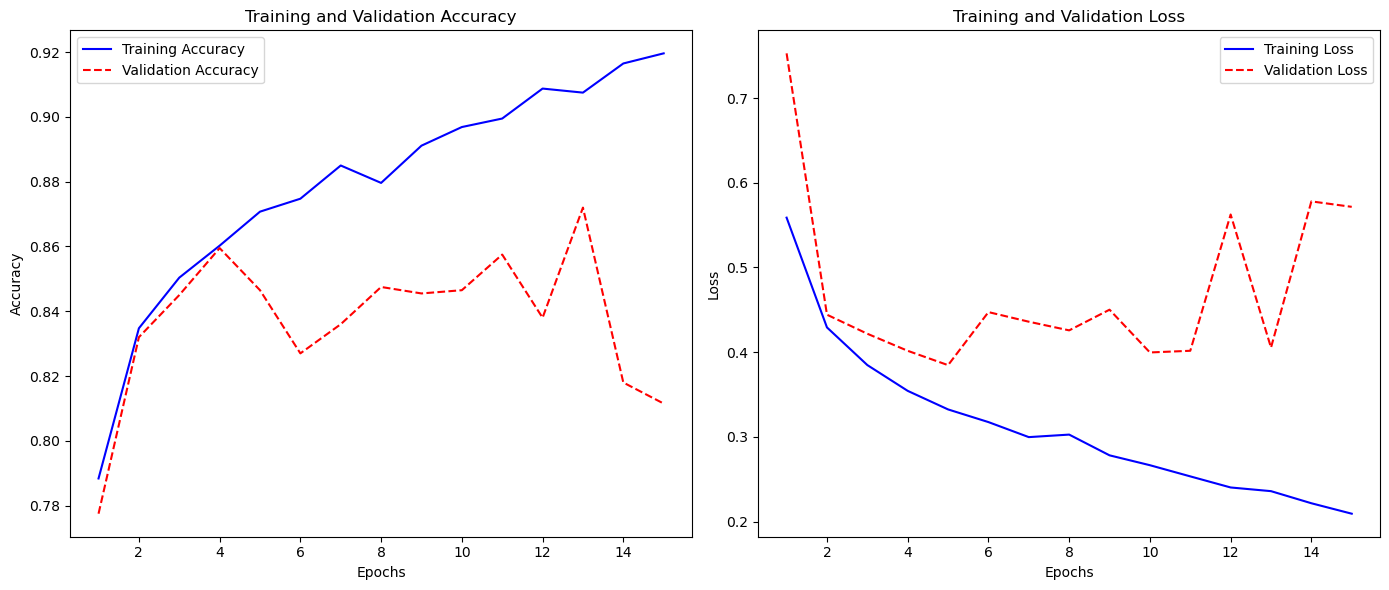


Average Accuracy across 5 folds: 0.8525


In [ ]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index], train_data_X[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_fnn_tf = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_training_history(history_fnn_tf)
    
# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


5-fold cross-validation with 100 components

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 1 Accuracy: 0.8625
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       415
           1       0.99      0.96      0.98       379
           2       0.82      0.91      0.86       388
           3       0.90      0.92      0.91       405
           4       0.77      0.69      0.73       413

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 1:
 [[352   0   9  15  39]
 [  2 365   1   7   4]
 [  5   2 352   4  25]
 [  8   2   9 371  15]
 [ 53   0  59  16 285]]


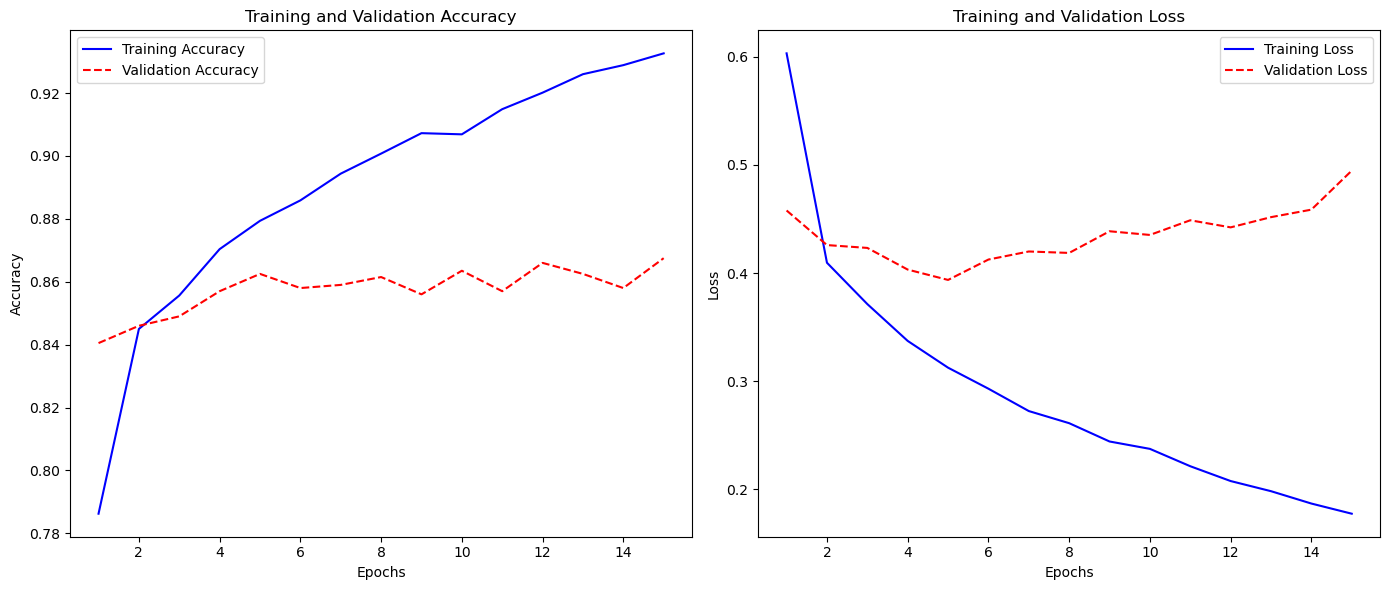

Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 2 Accuracy: 0.8605
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       398
           1       0.99      0.98      0.98       393
           2       0.87      0.88      0.87       425
           3       0.90      0.91      0.91       396
           4       0.77      0.67      0.72       388

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 2:
 [[344   1   5  12  36]
 [  3 385   1   4   0]
 [  9   0 372   9  35]
 [ 24   2   2 360   8]
 [ 67   2  46  13 260]]


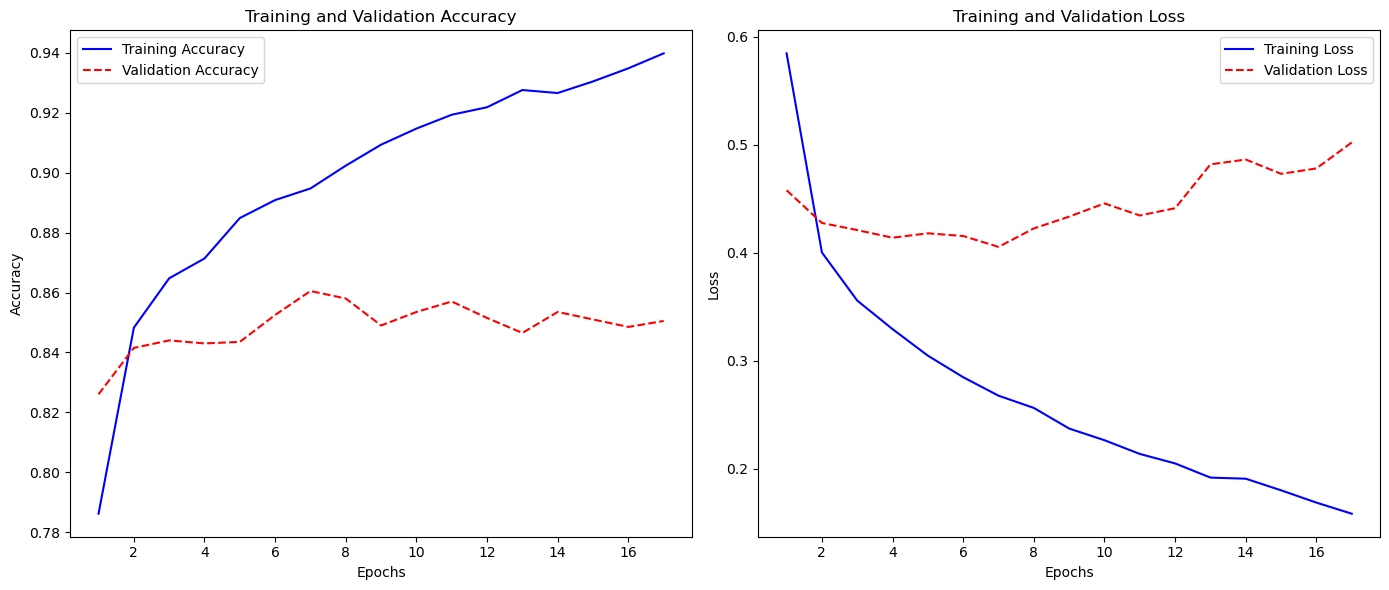

Training fold 3


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 3 Accuracy: 0.8580
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.79      0.84      0.82       399
           1       0.99      0.97      0.98       398
           2       0.84      0.87      0.85       366
           3       0.88      0.92      0.90       398
           4       0.79      0.70      0.74       439

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 3:
 [[337   1   9  15  37]
 [  1 387   1   8   1]
 [  4   1 317   7  37]
 [ 15   2   8 366   7]
 [ 70   0  41  19 309]]


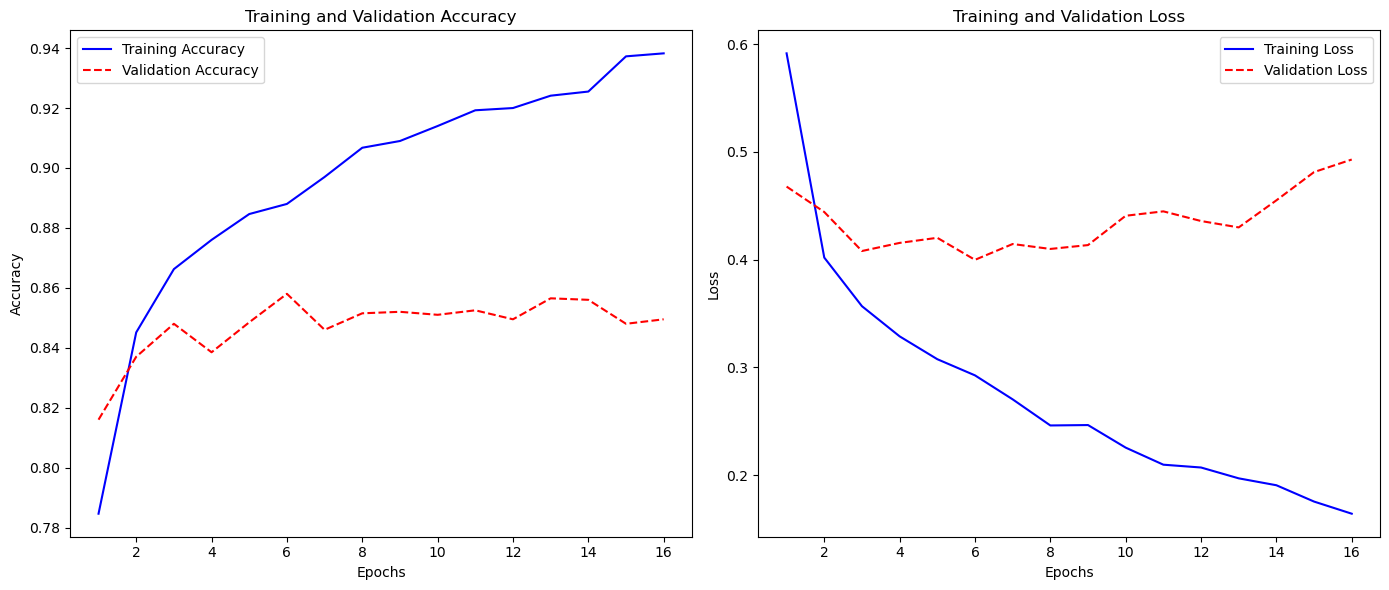

Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Fold 4 Accuracy: 0.8705
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.85      0.82      0.84       411
           1       0.99      0.97      0.98       414
           2       0.84      0.92      0.88       406
           3       0.91      0.93      0.92       396
           4       0.75      0.70      0.72       373

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 4:
 [[338   0   5  12  56]
 [  0 402   1  10   1]
 [  7   1 372   3  23]
 [  8   3   9 367   9]
 [ 44   0  55  12 262]]


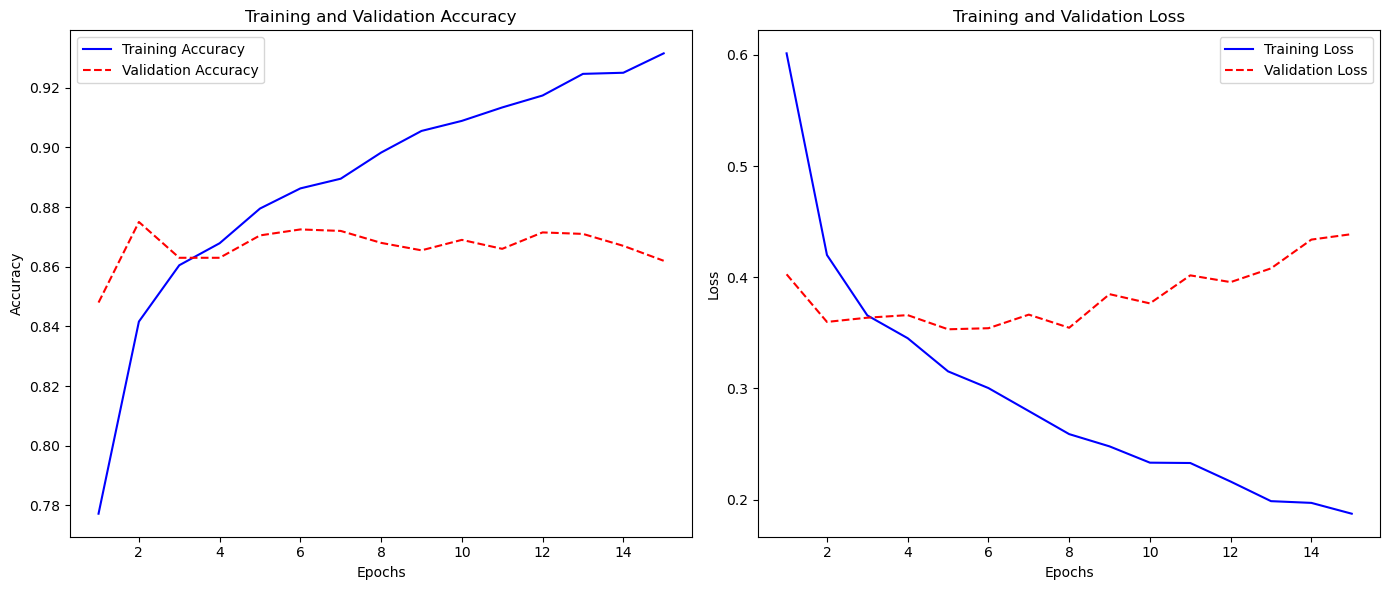

Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Fold 5 Accuracy: 0.8650
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       410
           1       0.96      0.96      0.96       363
           2       0.89      0.88      0.88       416
           3       0.91      0.90      0.90       410
           4       0.77      0.72      0.74       401

    accuracy                           0.86      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 5:
 [[358   2   2   7  41]
 [  4 350   0   8   1]
 [  9   3 365   7  32]
 [ 18   6   4 367  15]
 [ 53   4  39  15 290]]


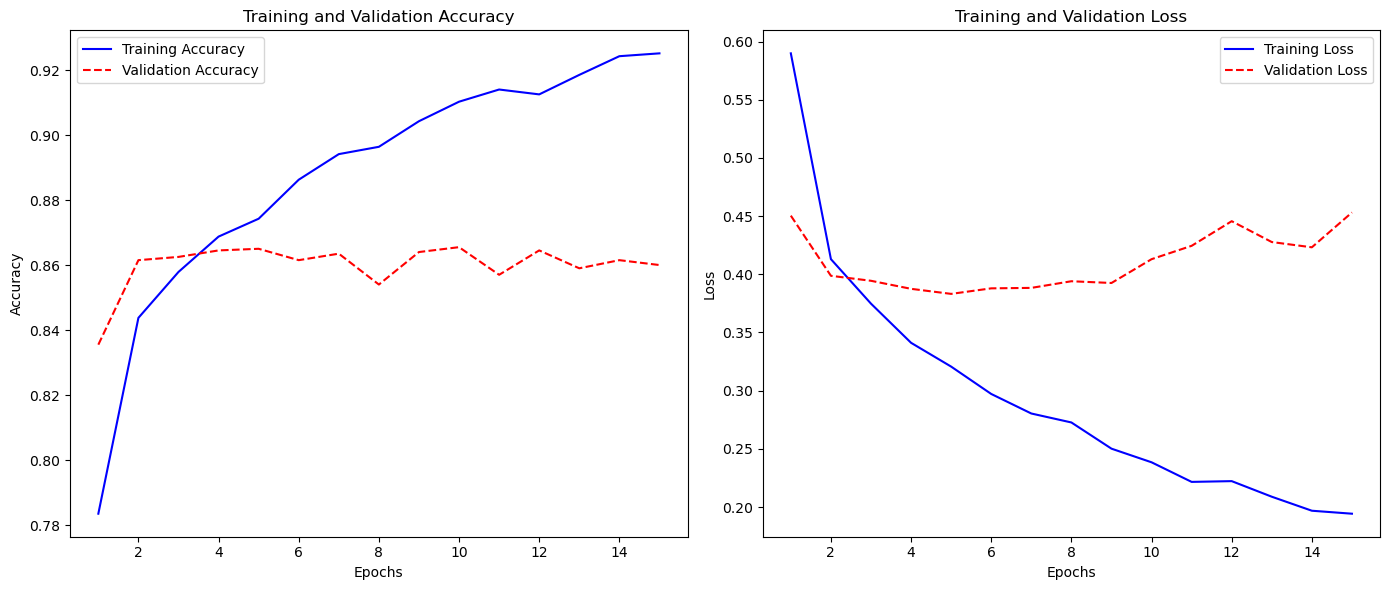


Average Accuracy across 5 folds: 0.8633


In [58]:
# pca
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(X_reduced_100)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = X_reduced_100[train_index], X_reduced_100[val_index]
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the model
    model = create_multiclass_model_pca(input_dim=X_reduced_100.shape[1], num_classes=len(np.unique(train_data_y)))
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_fnn_tf_100 = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Get the predicted class for each sample

    # Calculate accuracy for the current fold
    accuracy_pca = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy_pca)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy_pca:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_training_history(history_fnn_tf_100)
    
# Calculate the average accuracy across all folds
average_accuracy_pca = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy_pca:.4f}")

## 2.3 CNN

In [59]:
def create_cnn_model(input_shape, num_classes):
    model_cnn = Sequential()
    model_cnn.add(Conv2D(32, (3, 3), activation='leaky_relu', input_shape=input_shape))
    model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
    model_cnn.add(Conv2D(64, (3, 3), activation='leaky_relu'))
    model_cnn.add(MaxPooling2D(pool_size=(2, 2)))
    model_cnn.add(Flatten())
    model_cnn.add(Dense(256, activation='leaky_relu'))
    model_cnn.add(Dropout(0.5))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dense(128, activation='leaky_relu'))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dropout(0.3))
    model_cnn.add(Dense(64, activation='leaky_relu'))  # Second hidden layer
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dropout(0.2))
    model_cnn.add(Dense(32, activation='leaky_relu'))
    model_cnn.add(BatchNormalization())
    model_cnn.add(Dense(num_classes, activation='softmax'))  # Softmax for multi-class classification
    
    # Compile the model
    model_cnn.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model_cnn

In [103]:
def plot_training_history(history):
    # Extract accuracy and loss values for both training and validation
    accuracy = history.history['accuracy']
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(accuracy) + 1)

    # Plot Accuracy
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
    else:
        plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
        plt.title('Training and Validation Loss')
    else:
        plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Show the plots
    plt.tight_layout()
    plt.show()
    

Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 1 Accuracy: 0.8865
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.87      0.84      0.86       415
           1       0.99      0.97      0.98       379
           2       0.93      0.87      0.90       388
           3       0.89      0.96      0.92       405
           4       0.77      0.81      0.79       413

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix for Fold 1:
 [[348   0   7  11  49]
 [  1 367   1   7   3]
 [  4   1 338  12  33]
 [  3   2   0 387  13]
 [ 43   0  19  18 333]]


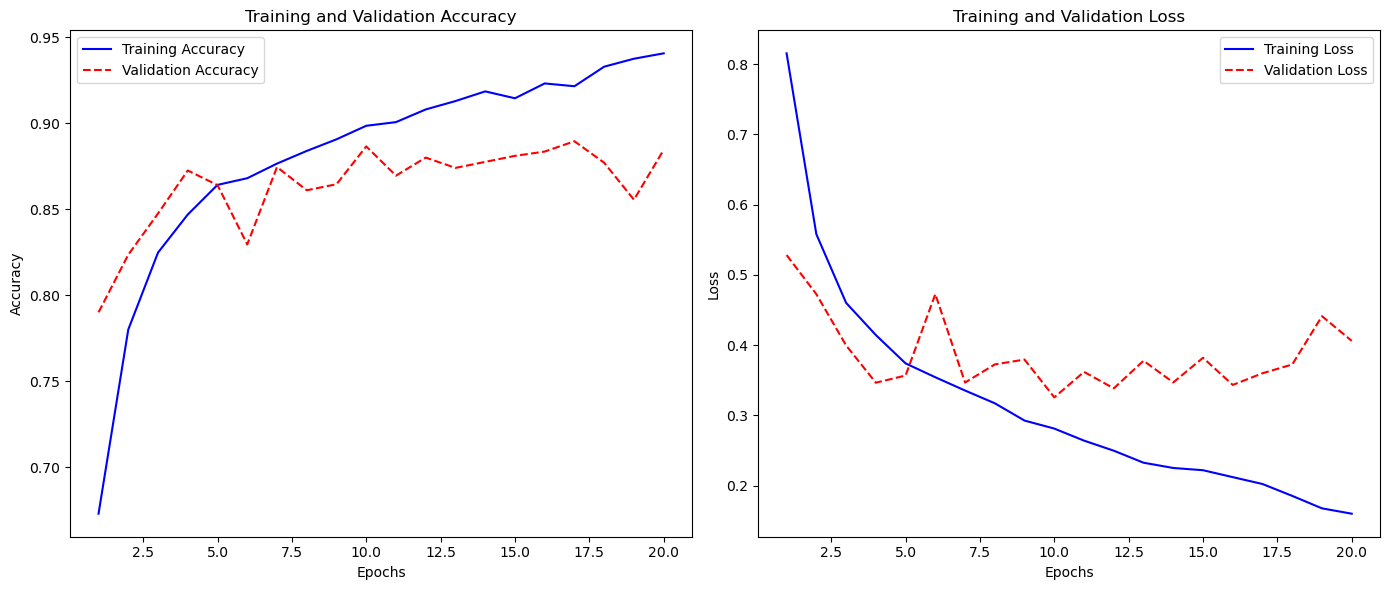

Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 2 Accuracy: 0.8705
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81       398
           1       0.97      0.99      0.98       393
           2       0.88      0.93      0.90       425
           3       0.90      0.93      0.91       396
           4       0.78      0.67      0.72       388

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 2:
 [[325   3   8  17  45]
 [  1 390   0   2   0]
 [  7   1 396   6  15]
 [  6   4   2 370  14]
 [ 61   3  46  18 260]]


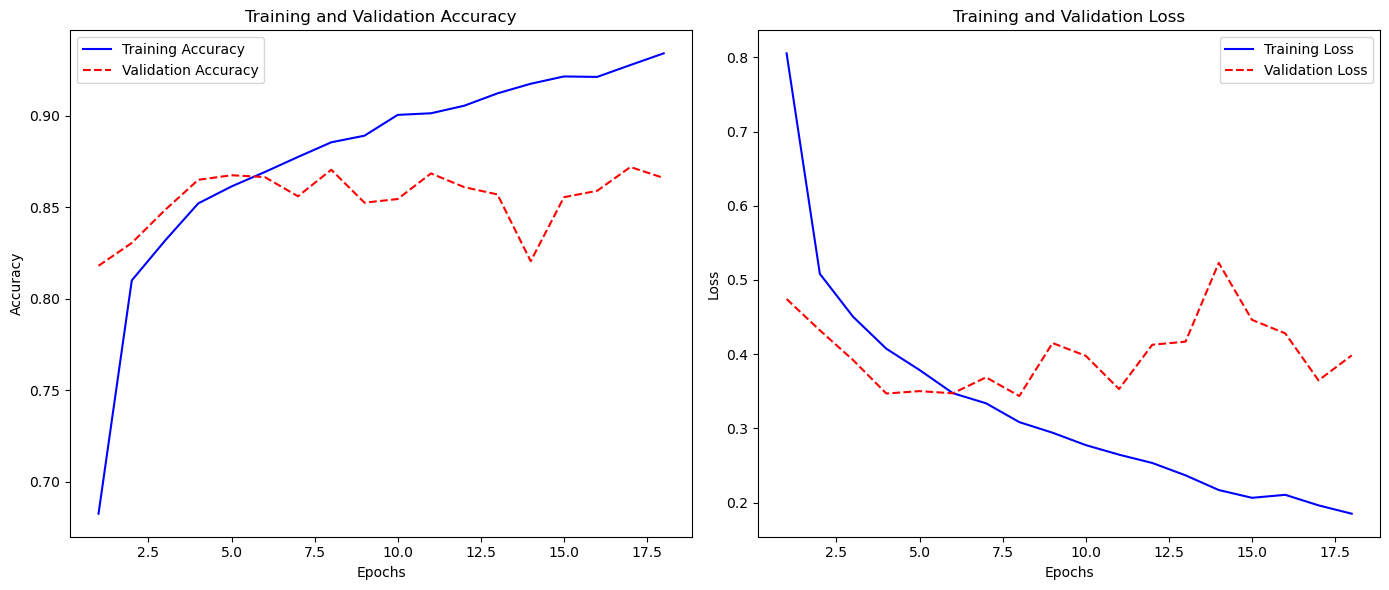

Training fold 3


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 3 Accuracy: 0.8710
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83       399
           1       0.99      0.97      0.98       398
           2       0.85      0.88      0.87       366
           3       0.91      0.93      0.92       398
           4       0.78      0.75      0.77       439

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Confusion Matrix for Fold 3:
 [[332   1  16  10  40]
 [  1 386   1   9   1]
 [  4   0 322   3  37]
 [  5   1   6 372  14]
 [ 60   2  32  15 330]]


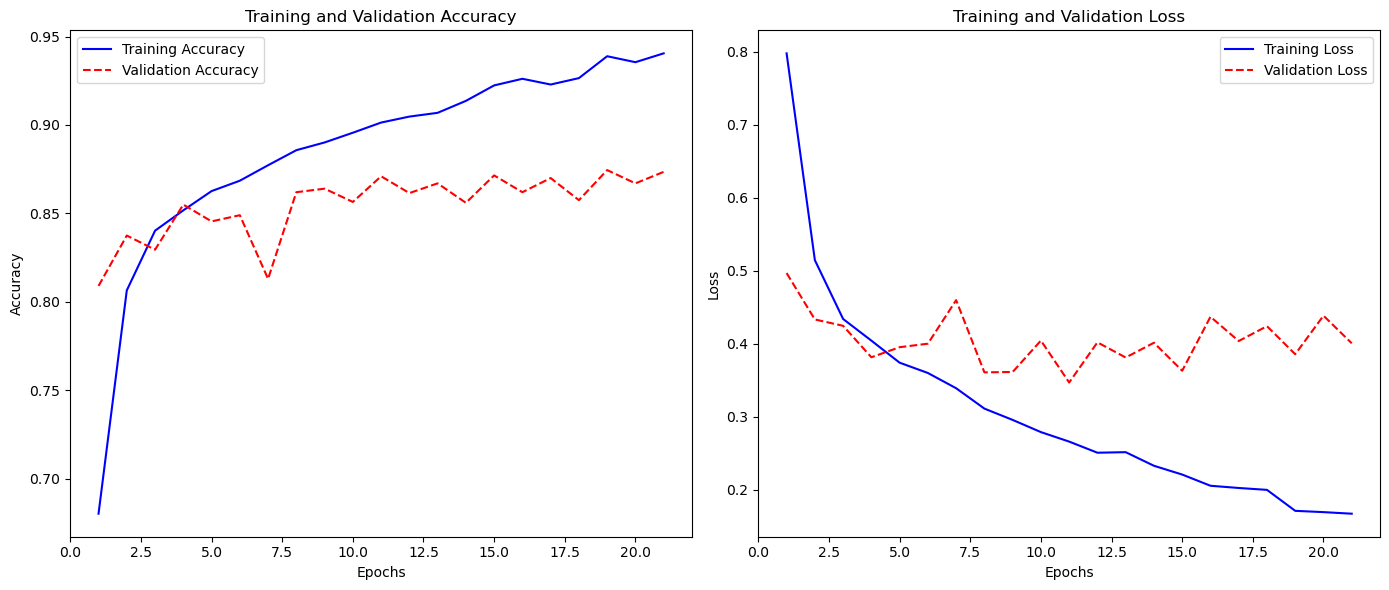

Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 4 Accuracy: 0.8855
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86       411
           1       0.99      0.96      0.98       414
           2       0.89      0.90      0.90       406
           3       0.91      0.94      0.93       396
           4       0.80      0.71      0.75       373

    accuracy                           0.89      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.89      0.88      2000

Confusion Matrix for Fold 4:
 [[371   1   3  12  24]
 [  2 399   0  11   2]
 [  8   1 364   4  29]
 [  9   2   2 374   9]
 [ 63   0  38   9 263]]


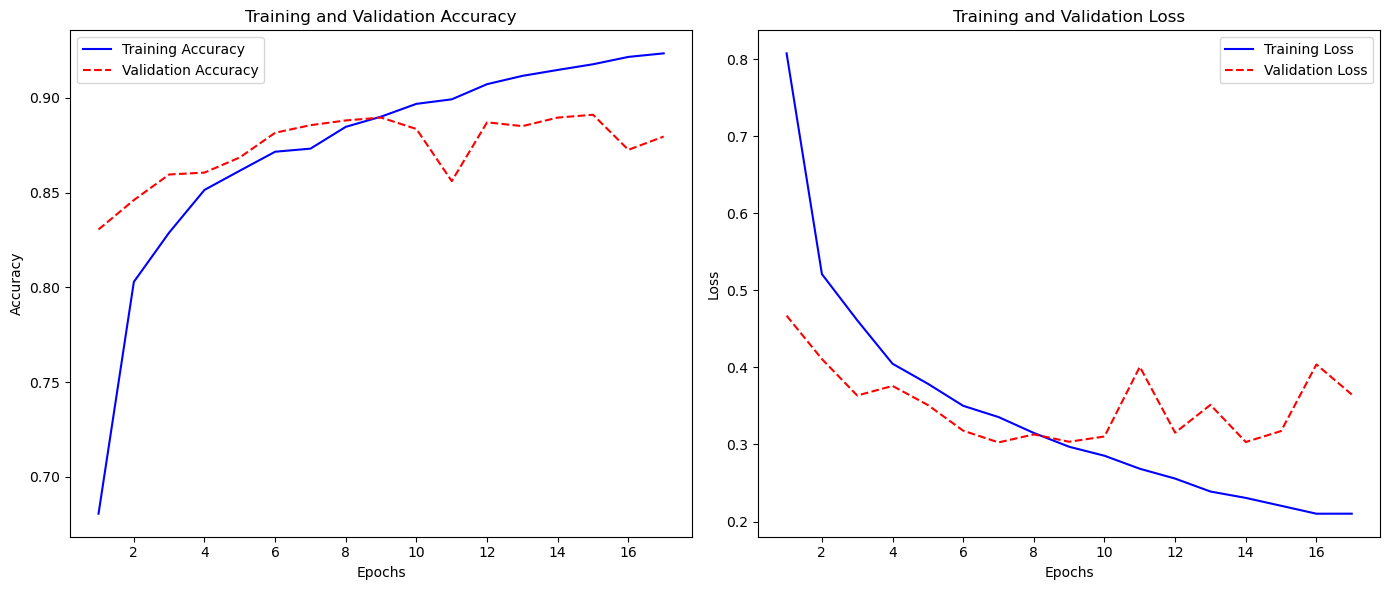

Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Fold 5 Accuracy: 0.8815
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86       410
           1       0.98      0.98      0.98       363
           2       0.87      0.92      0.89       416
           3       0.91      0.92      0.91       410
           4       0.86      0.69      0.76       401

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 5:
 [[372   0   5  14  19]
 [  0 355   0   8   0]
 [ 12   2 383   3  16]
 [ 13   4   6 377  10]
 [ 62   2  47  14 276]]


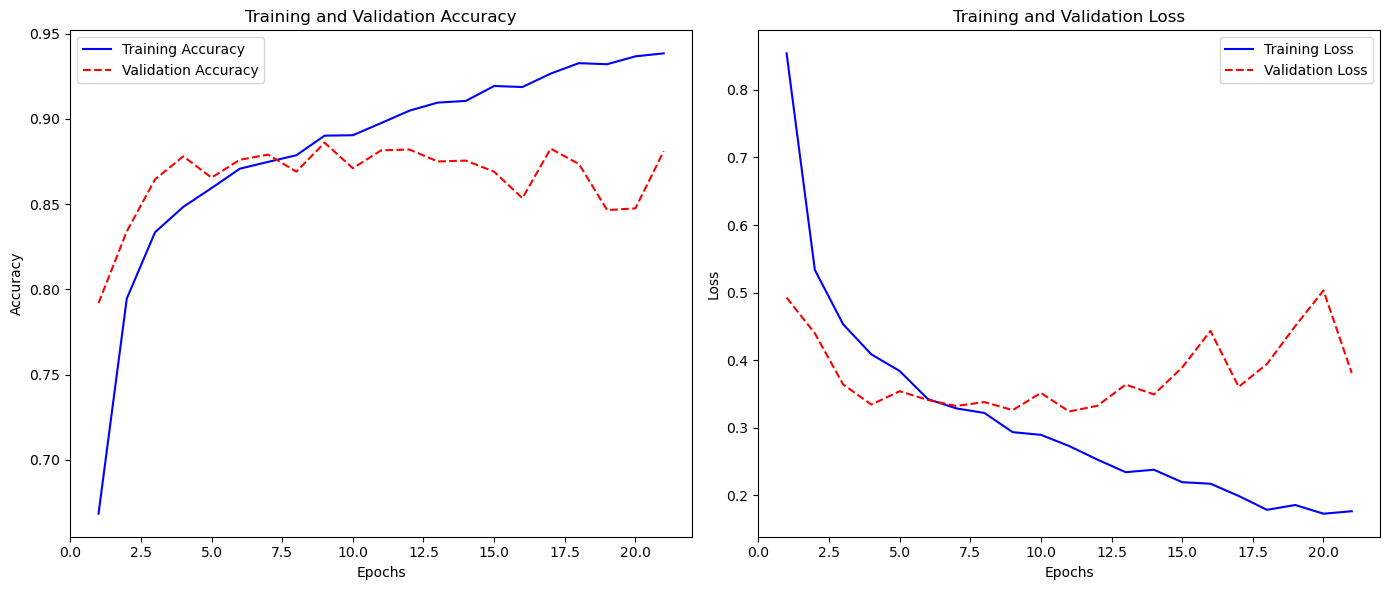


Average Accuracy across 5 folds: 0.8790


In [61]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train, X_val = train_data_X[train_index].reshape(-1, 28, 28, 1), train_data_X[val_index].reshape(-1, 28, 28, 1)
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the CNN model
    model = create_cnn_model(input_shape=(28, 28, 1), num_classes=len(np.unique(train_data_y)))
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop if no improvement after 10 epochs
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with validation and early stopping
    history_cnn = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_training_history(history_cnn)
    
# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


In [62]:

# Partial function for default Conv2D
DefaultConv2D = partial(tf.keras.layers.Conv2D, 
                        kernel_size=3, 
                        padding="same",
                        activation="leaky_relu", 
                        kernel_initializer="he_normal")

# Function to create CNN model
def create_cnn_from_book(input_shape, num_classes):
    model_book = tf.keras.Sequential([
        DefaultConv2D(filters=64, kernel_size=7, input_shape=input_shape),
        tf.keras.layers.MaxPool2D(),
        DefaultConv2D(filters=128),
        DefaultConv2D(filters=128),
        tf.keras.layers.MaxPool2D(),
        DefaultConv2D(filters=256),
        DefaultConv2D(filters=256),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units=128, activation="leaky_relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(units=64, activation="leaky_relu", kernel_initializer="he_normal"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(units=num_classes, activation="softmax")
    ])
    model_book.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model_book


Training fold 1


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Fold 1 Accuracy: 0.8955
Classification Report for Fold 1:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87       415
           1       0.98      0.98      0.98       379
           2       0.89      0.92      0.91       388
           3       0.94      0.93      0.94       405
           4       0.79      0.78      0.79       413

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

Confusion Matrix for Fold 1:
 [[360   0   5   6  44]
 [  2 372   1   2   2]
 [  2   1 357   5  23]
 [  5   5   2 378  15]
 [ 42   1  35  11 324]]


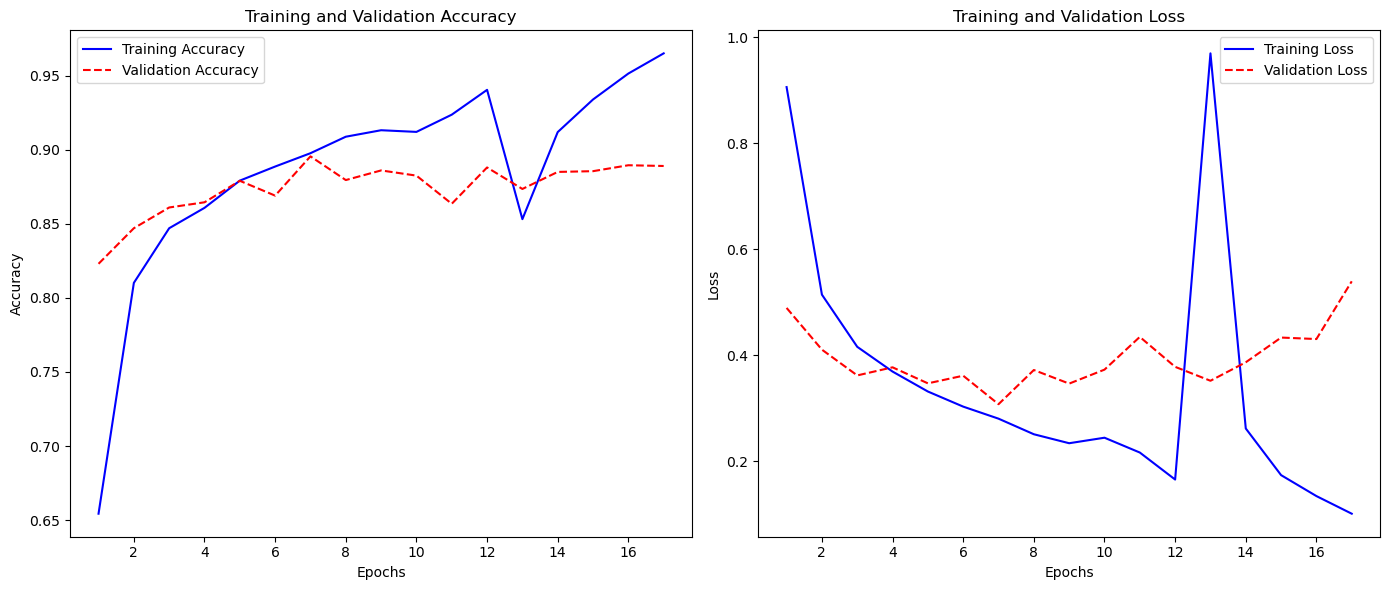

Training fold 2


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Fold 2 Accuracy: 0.8795
Classification Report for Fold 2:
               precision    recall  f1-score   support

           0       0.79      0.86      0.82       398
           1       0.99      0.99      0.99       393
           2       0.91      0.90      0.91       425
           3       0.94      0.90      0.92       396
           4       0.77      0.74      0.76       388

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 2:
 [[341   0   9   8  40]
 [  2 389   0   2   0]
 [  9   0 384   3  29]
 [ 18   2   3 358  15]
 [ 64   1  26  10 287]]


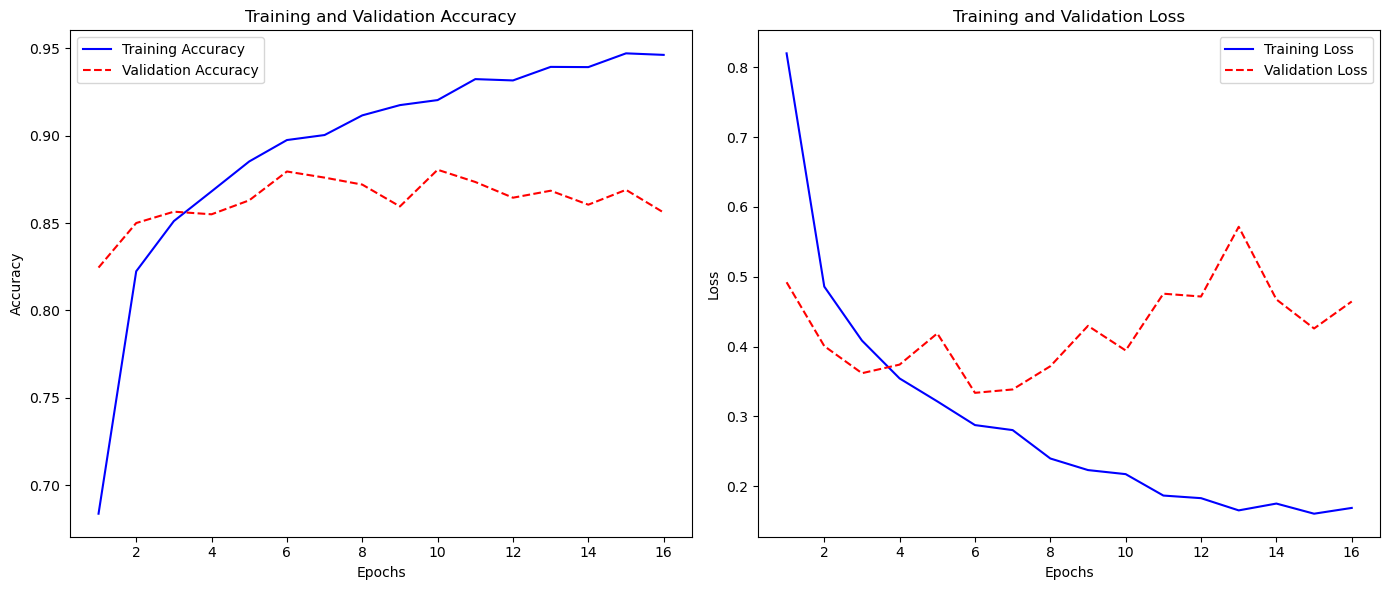

Training fold 3


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Fold 3 Accuracy: 0.8610
Classification Report for Fold 3:
               precision    recall  f1-score   support

           0       0.74      0.89      0.81       399
           1       0.99      0.98      0.98       398
           2       0.91      0.84      0.87       366
           3       0.89      0.91      0.90       398
           4       0.80      0.70      0.75       439

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Confusion Matrix for Fold 3:
 [[356   0   3  16  24]
 [  0 389   0   8   1]
 [ 11   0 308   3  44]
 [ 23   2   3 363   7]
 [ 90   1  26  16 306]]


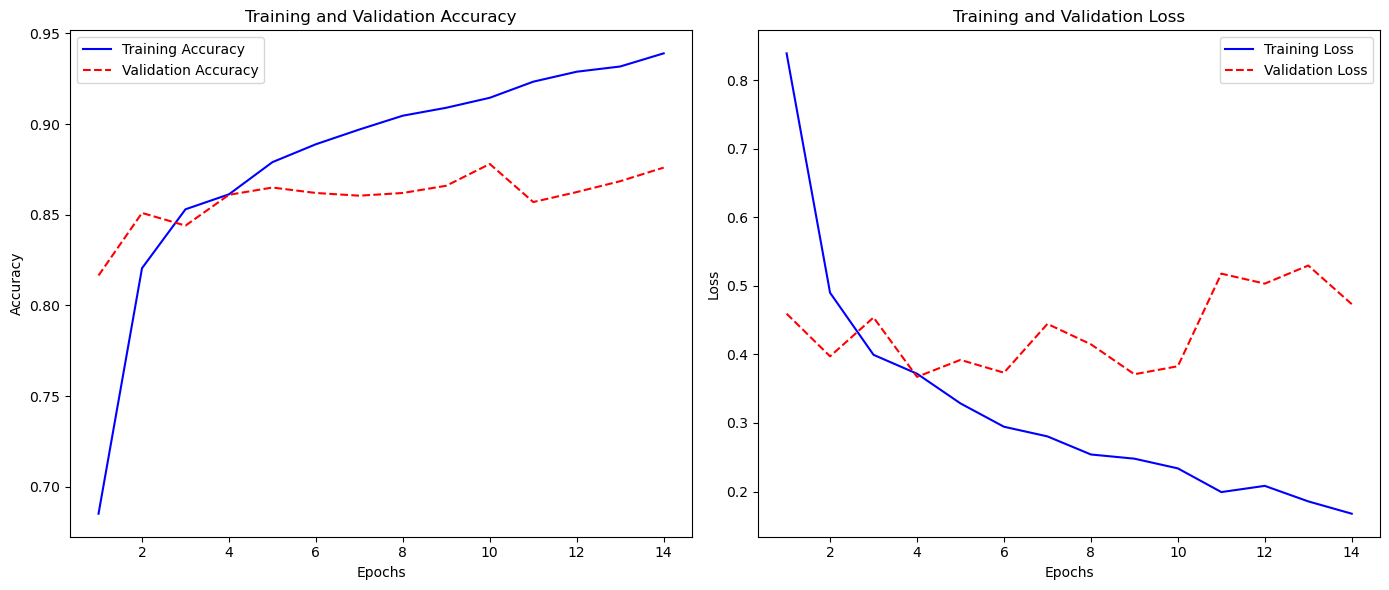

Training fold 4


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Fold 4 Accuracy: 0.8865
Classification Report for Fold 4:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86       411
           1       1.00      0.97      0.98       414
           2       0.88      0.92      0.90       406
           3       0.95      0.92      0.93       396
           4       0.76      0.73      0.75       373

    accuracy                           0.89      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix for Fold 4:
 [[360   0   5   6  40]
 [  0 402   3   4   5]
 [  6   0 374   4  22]
 [  7   2   3 363  21]
 [ 53   0  39   7 274]]


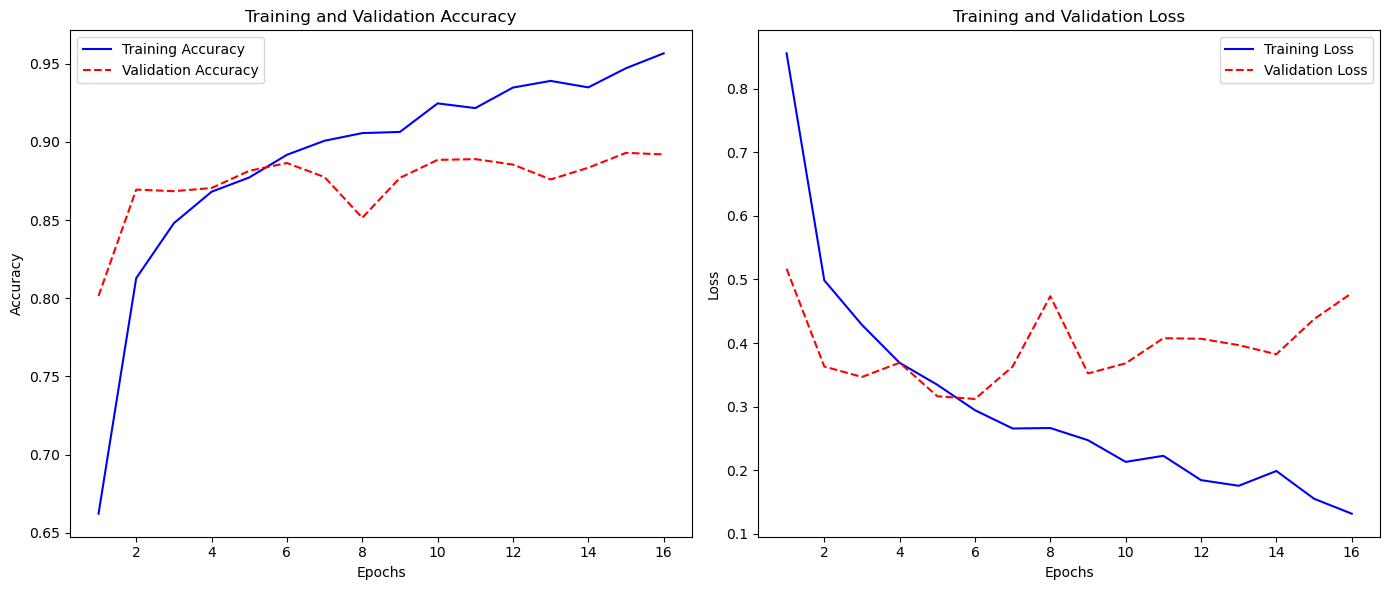

Training fold 5


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Fold 5 Accuracy: 0.8845
Classification Report for Fold 5:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       410
           1       0.99      0.98      0.98       363
           2       0.92      0.87      0.90       416
           3       0.90      0.96      0.93       410
           4       0.82      0.72      0.77       401

    accuracy                           0.88      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix for Fold 5:
 [[369   0   3  15  23]
 [  0 356   0   5   2]
 [ 12   0 363   9  32]
 [  7   3   0 392   8]
 [ 67   1  28  16 289]]


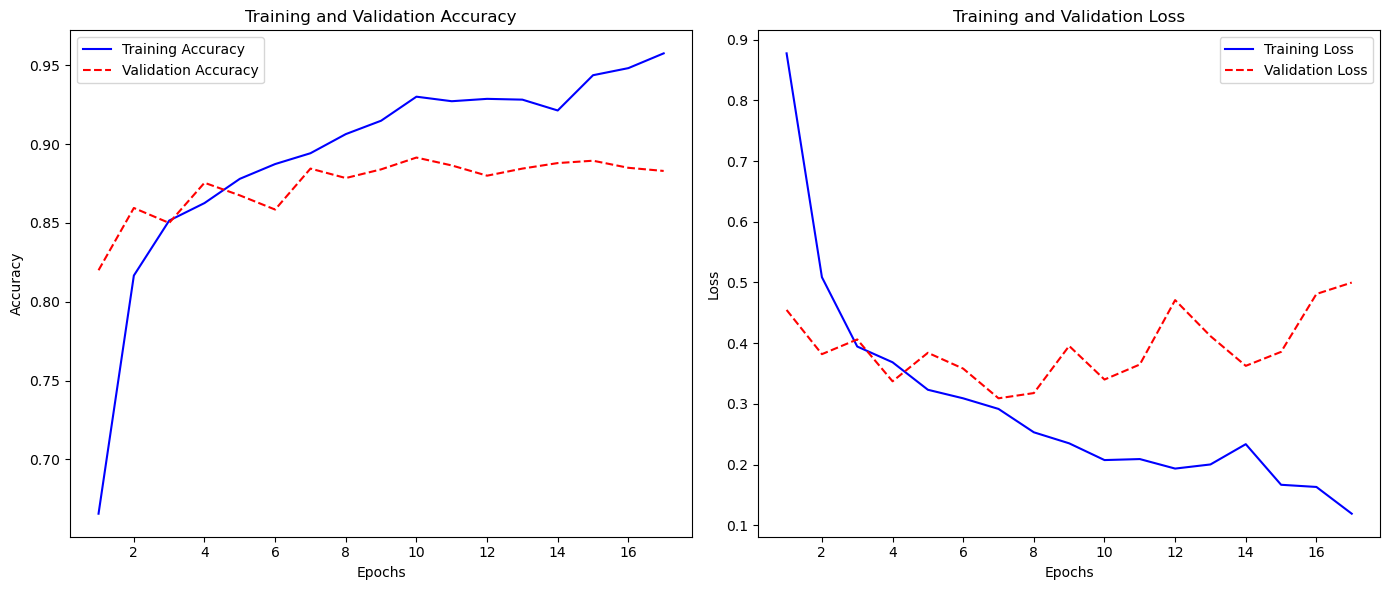


Average Accuracy across 5 folds: 0.8814


In [63]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
all_classification_reports = []
all_confusion_matrices = []

for fold, (train_index, val_index) in enumerate(kf.split(train_data_X)):
    print(f"Training fold {fold + 1}")
    
    # Split the data into training and validation sets for the current fold
    X_train = (train_data_X[train_index] / 255.0).reshape(-1, 28, 28, 1)  # Normalize and reshape for Conv2D input
    X_val = (train_data_X[val_index] / 255.0).reshape(-1, 28, 28, 1)      # Normalize and reshape for Conv2D input
    y_train, y_val = train_data_y[train_index], train_data_y[val_index]
    
    # Create a new instance of the CNN model
    model1 = create_cnn_from_book(input_shape=(28, 28, 1), num_classes=5)
    
    # Define EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=10,         # Stop training after 10 epochs with no improvement
        restore_best_weights=True  # Restore weights from the best epoch
    )
    
    # Train the model with early stopping
    history_book = model1.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Validation data for early stopping
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping]
    )
    
    # Evaluate the model on the validation set
    y_val_pred = np.argmax(model1.predict(X_val), axis=1)  # Convert probabilities to class predictions
    
    # Calculate accuracy for the current fold
    accuracy = accuracy_score(y_val, y_val_pred)
    fold_accuracies.append(accuracy)

    # Generate classification report and confusion matrix for detailed metrics
    class_report = classification_report(y_val, y_val_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_val, y_val_pred)
    
    # Store the classification report and confusion matrix for the fold
    all_classification_reports.append(class_report)
    all_confusion_matrices.append(conf_matrix)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    print(f"Classification Report for Fold {fold + 1}:\n", classification_report(y_val, y_val_pred))
    print(f"Confusion Matrix for Fold {fold + 1}:\n", conf_matrix)
    plot_training_history(history_book)
    
# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"\nAverage Accuracy across 5 folds: {average_accuracy:.4f}")


# Final tests

Evaluate performance on fashion_test.npy. 

In [96]:
build_in_dt=tree.DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=10)
dt_from_scratch=DecisionTreeFromScratch(max_depth=10, min_leaf=10)
build_in_fnn=create_multiclass_model_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
fnn_from_scratch=create_multiclass_model_from_scratch_raw(input_dim=train_data_X.shape[1], num_classes=len(np.unique(train_data_y)))
build_in_cnn=create_cnn_model(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))
cnn_from_book=create_cnn_from_book(input_shape=train_data_X.reshape(-1, 28, 28, 1).shape[1:], num_classes=len(np.unique(train_data_y)))

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Test the tree models
### Skitlern model

Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1005
           1       0.92      0.93      0.92       982
           2       0.80      0.75      0.77      1067
           3       0.83      0.80      0.82      1034
           4       0.55      0.60      0.58       912

    accuracy                           0.77      5000
   macro avg       0.77      0.77      0.77      5000
weighted avg       0.77      0.77      0.77      5000

Confusion Matrix:
[[743   9  21  57 175]
 [ 12 916  12  27  15]
 [ 31  16 800  25 195]
 [ 63  44  30 832  65]
 [151  15 137  59 550]]


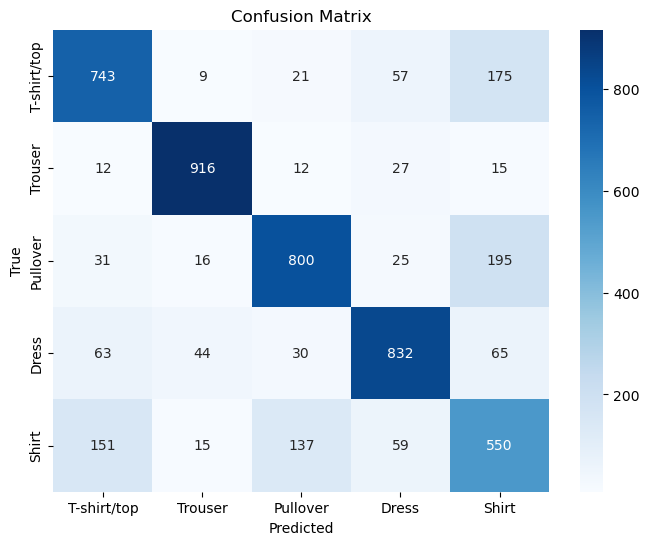

In [65]:
build_in_dt.fit(X_reduced_100,train_data_y)
predicted_y=build_in_dt.predict(test_X_reduced_100)

# Evaluate accuracy
accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix1 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix1)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      1091
           1       0.92      0.95      0.94       963
           2       0.83      0.76      0.79      1092
           3       0.86      0.78      0.82      1108
           4       0.48      0.65      0.55       746

    accuracy                           0.77      5000
   macro avg       0.77      0.77      0.77      5000
weighted avg       0.79      0.77      0.78      5000

Confusion Matrix:
[[768   7  29  81 206]
 [  8 918   8  23   6]
 [ 22  11 828  12 219]
 [ 78  52  30 862  86]
 [124  12 105  22 483]]


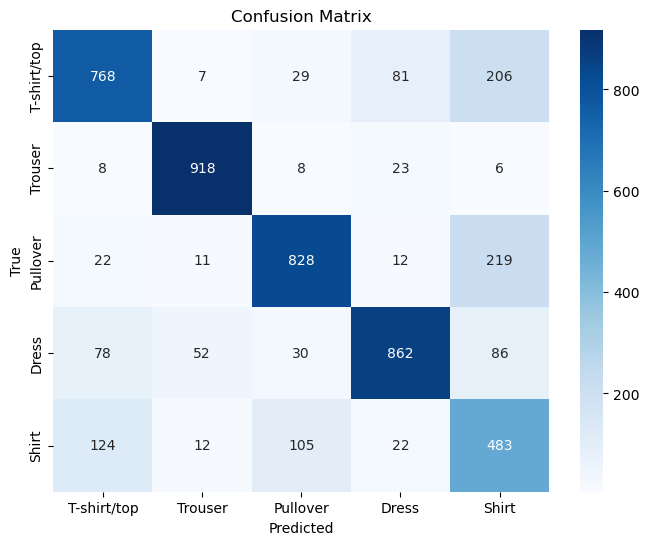

In [66]:
dt_from_scratch.fit(X_reduced_100,train_data_y)
predicted_y=dt_from_scratch.predict(test_X_reduced_100)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix2 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix2)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Test the Feed-forward neural networks models
### Tensorflow implementation

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7595 - loss: 0.6333
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8471 - loss: 0.4022
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8540 - loss: 0.3855
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8610 - loss: 0.3574
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8743 - loss: 0.3165
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8639 - loss: 0.3299
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8865 - loss: 0.2981
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8887 - loss: 0.2805
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8985 - loss: 0.2658
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8925 - loss: 0.2745


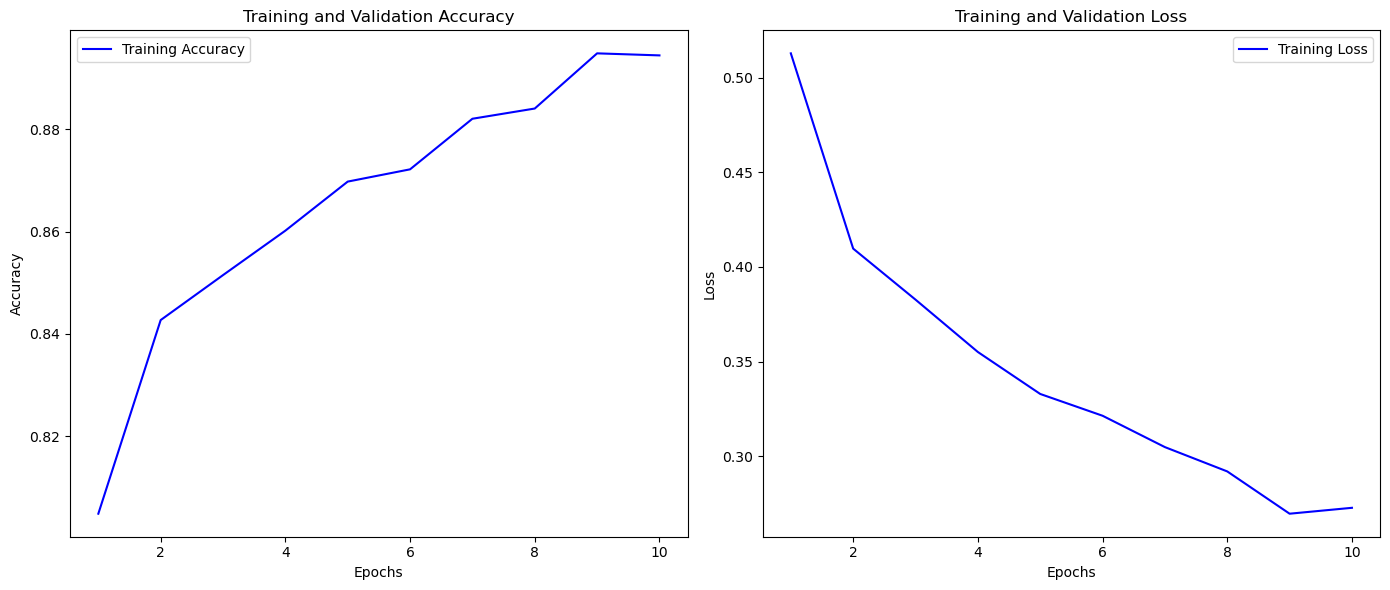

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1274
           1       0.98      0.83      0.90      1183
           2       0.90      0.76      0.82      1182
           3       0.76      0.92      0.83       823
           4       0.44      0.82      0.57       538

    accuracy                           0.79      5000
   macro avg       0.79      0.81      0.78      5000
weighted avg       0.84      0.79      0.81      5000

Confusion Matrix:
[[895   2  38  73 266]
 [ 32 977  12 142  20]
 [ 16   7 900  12 247]
 [ 13  12  14 757  27]
 [ 44   2  36  16 440]]


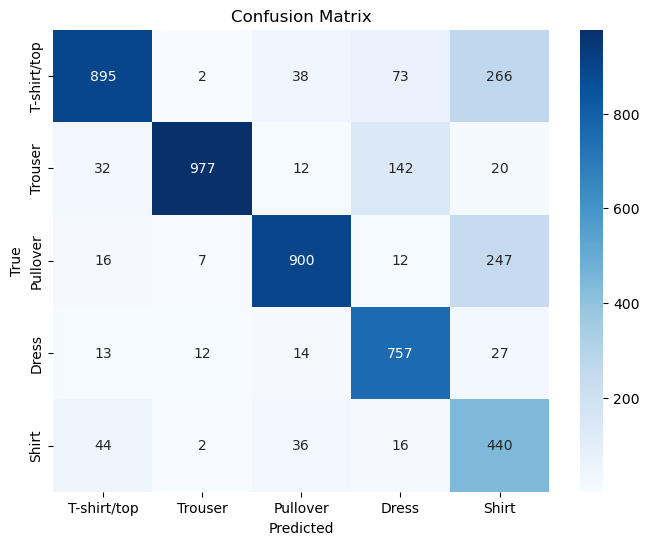

In [67]:

history1=build_in_fnn.fit(train_data_X, train_data_y, epochs=10, batch_size=32)
plot_training_history(history1)
predicted_y=np.argmax(build_in_fnn.predict(test_data_X), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix3 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix3)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix3, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Our implemntation

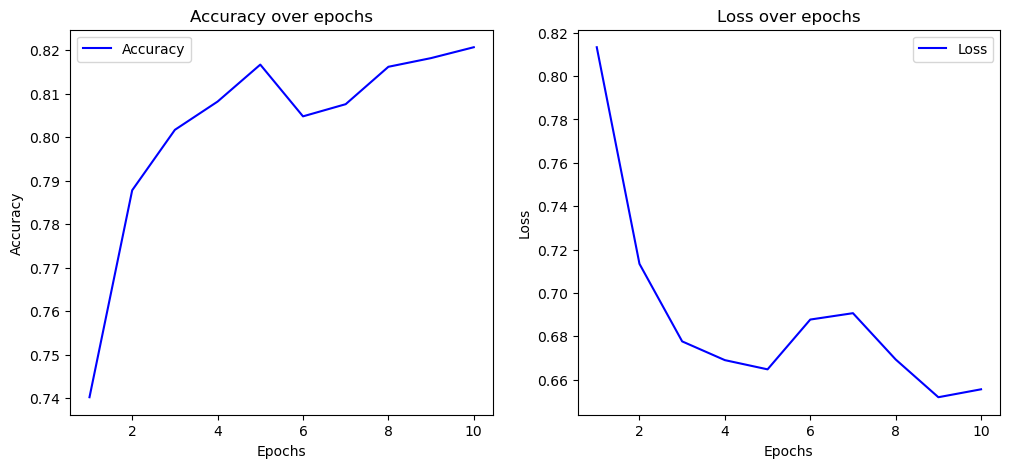

Accuracy: 0.79
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.74       956
           1       0.94      0.98      0.96       952
           2       0.84      0.77      0.80      1085
           3       0.81      0.89      0.85       918
           4       0.63      0.58      0.61      1089

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.78      0.79      0.78      5000

Confusion Matrix:
[[719  14  17  57 149]
 [  3 935   0  12   2]
 [ 21  15 838  16 195]
 [ 42  25  16 813  22]
 [215  11 129 102 632]]


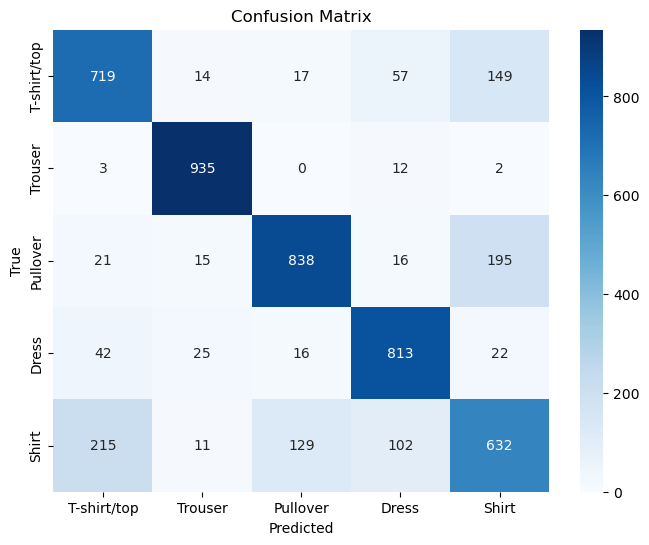

In [ ]:
y_train = one_hot_encode(train_data_y, 5).T
fnn_from_scratch.fit(train_data_X.T, y_train, epochs=20, batch_size=32)
plot_metrics(fnn_from_scratch.metrics)
predicted_y=np.argmax(fnn_from_scratch.predict(test_data_X.T), axis=0)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix4 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix4)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix4, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test Convolutional neural network

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6049 - loss: 0.9837
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8023 - loss: 0.5232
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8342 - loss: 0.4461
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8539 - loss: 0.3981
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8650 - loss: 0.3612
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8745 - loss: 0.3435
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8801 - loss: 0.3117
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8825 - loss: 0.3077
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8922 - loss: 0.2826
Epoch 10/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8929 - loss: 0.2820
Epoch 11/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9086 - loss: 0.2550
Epoch 12/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

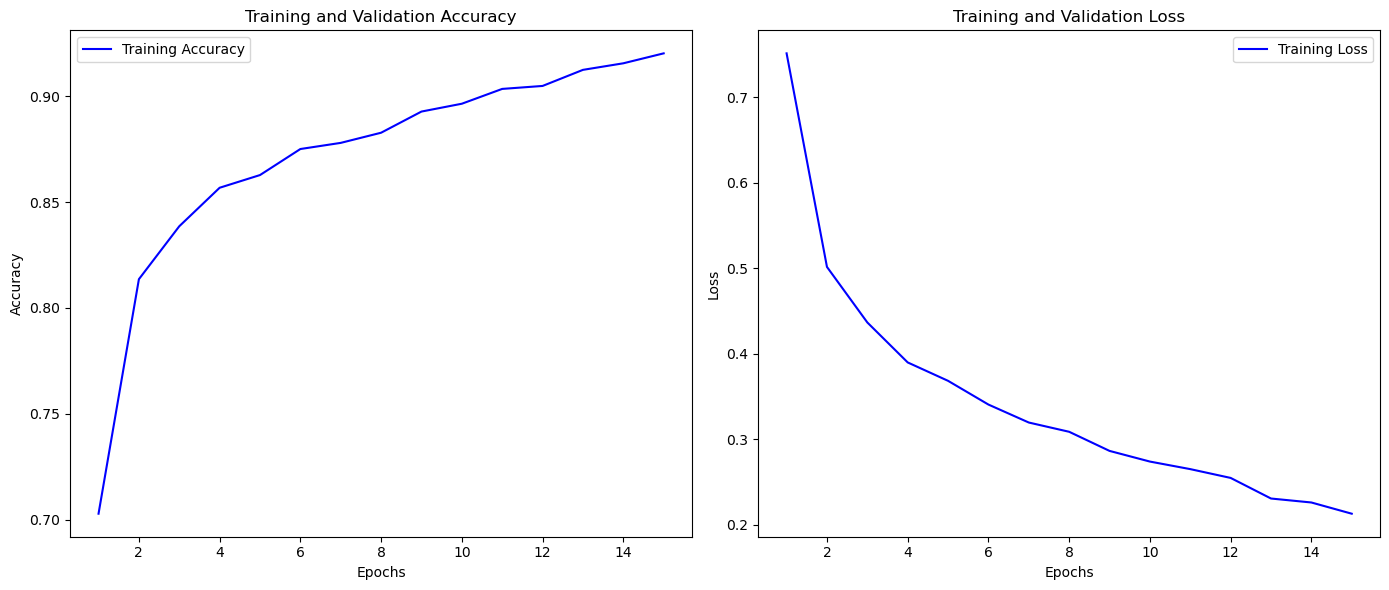

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.872
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       945
           1       0.97      1.00      0.98       973
           2       0.89      0.87      0.88      1018
           3       0.93      0.92      0.92      1018
           4       0.76      0.73      0.75      1046

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

Confusion Matrix:
[[809   3  16  17 100]
 [  1 971   1   0   0]
 [ 19   1 885  10 103]
 [ 21  21  11 932  33]
 [150   4  87  41 764]]


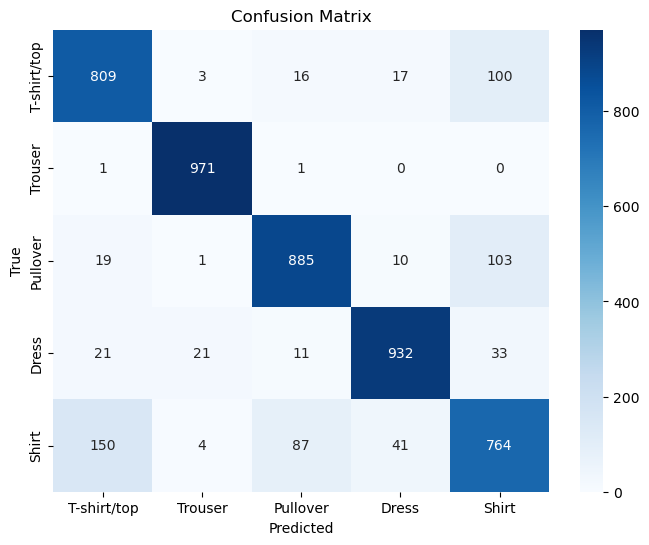

In [98]:
history2=build_in_cnn.fit(train_data_X.reshape(-1, 28, 28,1), train_data_y, epochs=15, batch_size=32, verbose=1)
plot_training_history(history2)
predicted_y=np.argmax(build_in_cnn.predict(test_data_X.reshape(-1, 28, 28,1)), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.3f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix5 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix5)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix5, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7817 - loss: 0.8341
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7822 - loss: 0.7704
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.7742 - loss: 0.7297
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7713 - loss: 0.7754
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6293 - loss: 5.5946
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7455 - loss: 0.9747
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7970 - loss: 0.5758
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8240 - loss: 0.4931
Epoch 9/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8155 - loss: 0.5126
Epoch 10/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8267 - loss: 0.4832
Epoch 11/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8394 - loss: 0.4324
Epoch 12/15
313/313 ━━━━━━━━━━

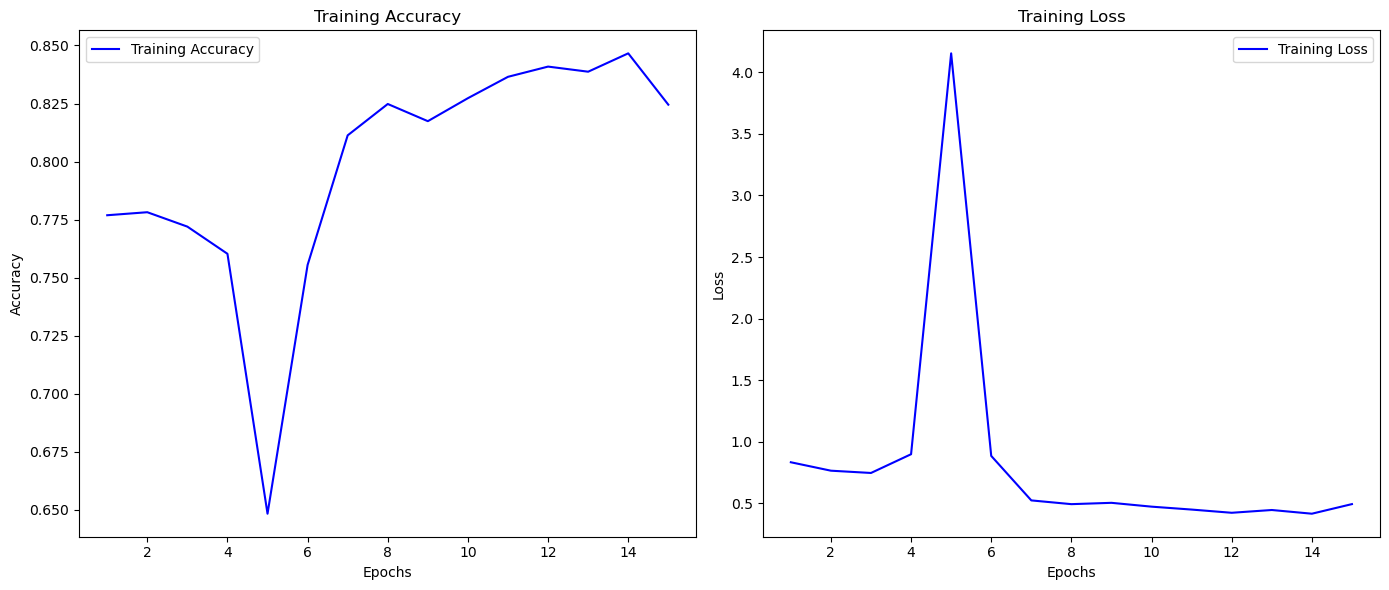

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Accuracy: 0.817
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       939
           1       0.98      0.99      0.98       990
           2       0.75      0.95      0.83       788
           3       0.75      0.97      0.85       769
           4       0.84      0.55      0.67      1514

    accuracy                           0.82      5000
   macro avg       0.82      0.86      0.83      5000
weighted avg       0.83      0.82      0.81      5000

Confusion Matrix:
[[774   1   6  37 121]
 [  1 979   2   6   2]
 [  5   0 746   3  34]
 [  6   6   4 748   5]
 [214  14 242 206 838]]


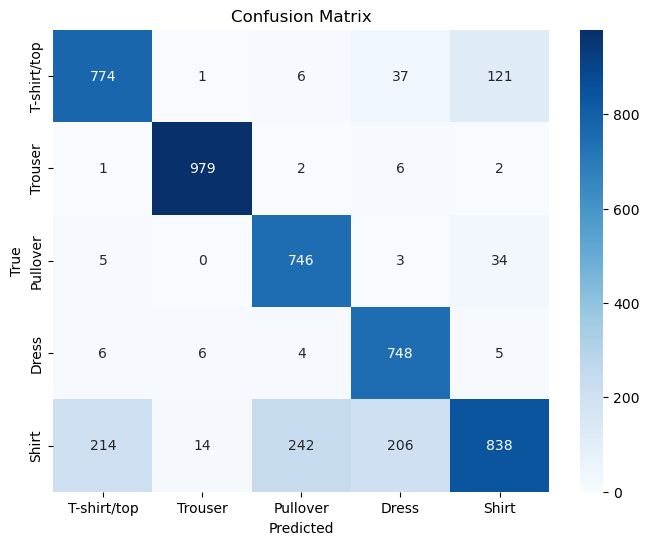

In [107]:
history3=cnn_from_book.fit(train_data_X.reshape(-1, 28, 28,1), train_data_y, epochs=15, batch_size=32, verbose=1)
plot_training_history(history3)
predicted_y=np.argmax(cnn_from_book.predict(test_data_X.reshape(-1, 28, 28,1)), axis=1)

accuracy = accuracy_score(predicted_y, test_data_y)
print(f"Accuracy: {accuracy:.3f}")

# Classification report
print("Classification Report:")
print(classification_report(predicted_y, test_data_y))

# Confusion matrix
conf_matrix5 = confusion_matrix(predicted_y, test_data_y)
print("Confusion Matrix:")
print(conf_matrix5)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix5, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()